# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 11     |  |
| :-------------|:-------------|
| Hugo Rutten | 6541593 |
| Yael Jawahierkhan | 6444504 |
| Matteo Leonardi | 6391494 |

In [16]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Yael Jawahierkhan','Matteo Leonardi']

## Opdracht 1: Planning.

| Planning Groep: 11     |Tijdstip / Tijdspanne  |
|---|---|
| Kalibreren van de sensor af | 11:30 |
| Testen meetopstelling | 12:00 |
| Algoritme iteratie 0 af | 15:00 |
| Iteraties maken | 16:30 |
| Alles testen en opruimen | 16:30-17:30 |
| groep aanwezig 1| 10:45 |
| Pauze 1| 12:45-13:45 |


## Opdracht 2: Import libs.

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [11]

<img src="KalibratieOpstelling.jpeg" width="400">

a= 0.03440668755754128
b =  0.3237959096074584


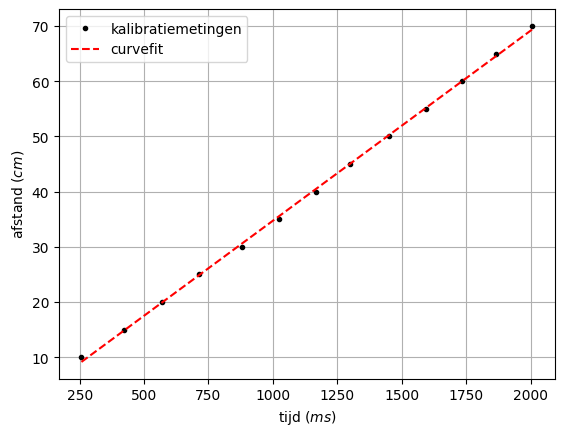

In [18]:
# verwerk hier jullie kalibratiemetingen
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


tijden = np.array([257,424,569,715,881,1023,1167,1301,1450,1595,1735,1867,2007]) #ms
afstanden = np.array([10.0,15.0,20.0, 25.0,30.0,35.0,40.0,45.0,50.0,55.0,60.0,65.0,70.0]) #cm

x_test = np.linspace(np.min(tijden),np.max(tijden))

def fit(x,a,b):
    return a*x+b

val, cov = curve_fit(fit,tijden,afstanden)

print('a=', val[0])
print( 'b = ', val[1])


plt.figure()
plt.plot(tijden,afstanden,'k.',label='kalibratiemetingen')
plt.plot(x_test,fit(x_test,*val),'r--',label='curvefit')
plt.ylabel('afstand $(cm)$')
plt.xlabel('tijd $(ms)$')
plt.grid()
plt.legend()
plt.show()


## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  44.47
1   0  30   0  20  45.52
2  40   0  30   0  47.95
3  30   0  20   0  47.58


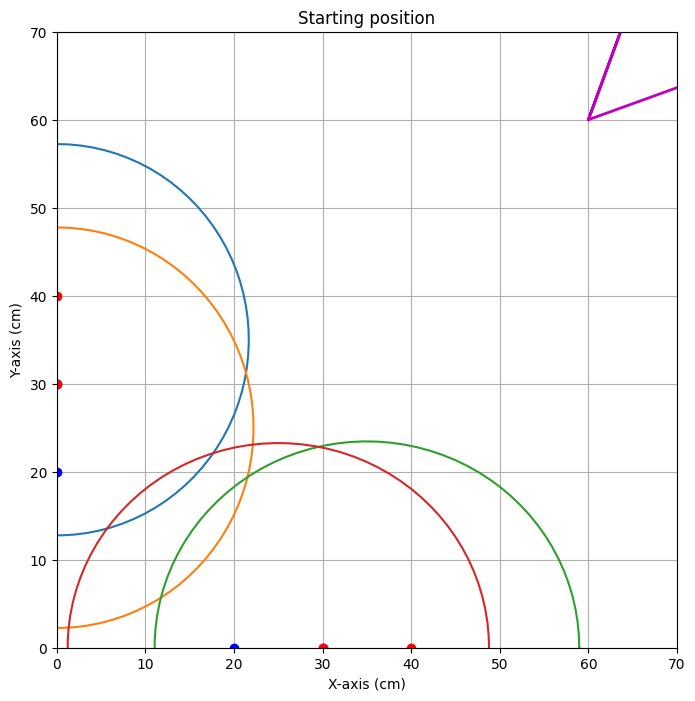


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=95.575


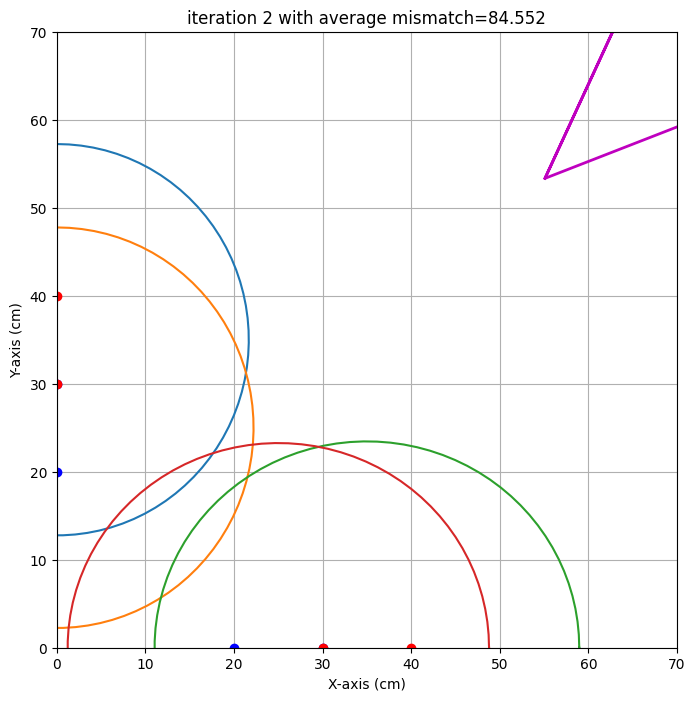

end iteration 2 with average mismatch=84.552


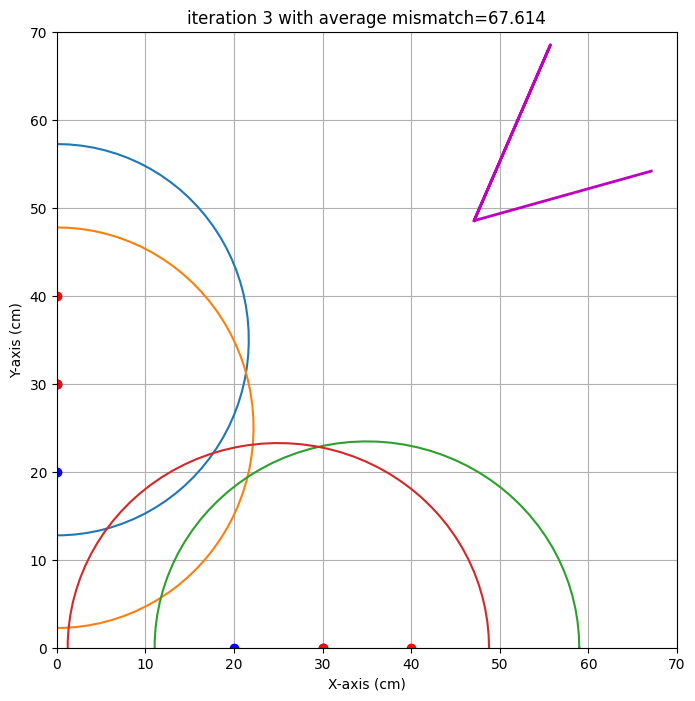

end iteration 3 with average mismatch=67.614


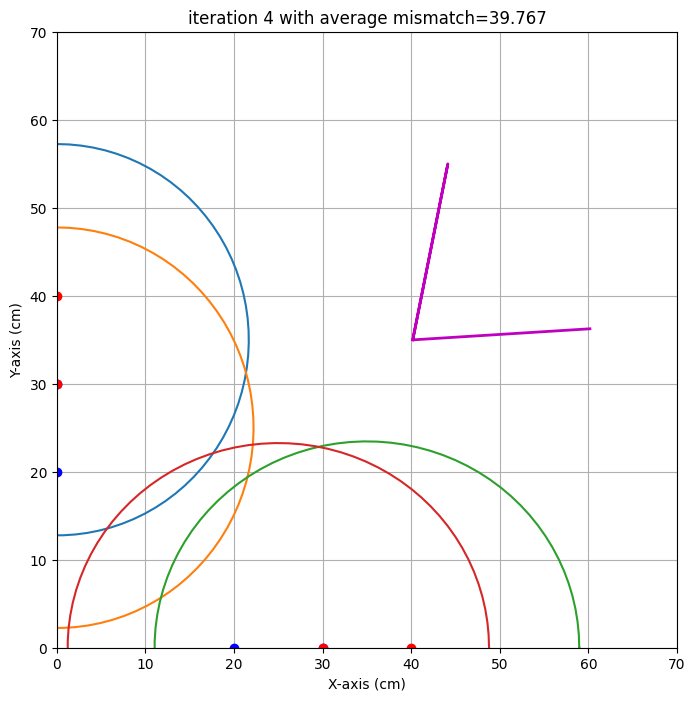

end iteration 4 with average mismatch=39.767


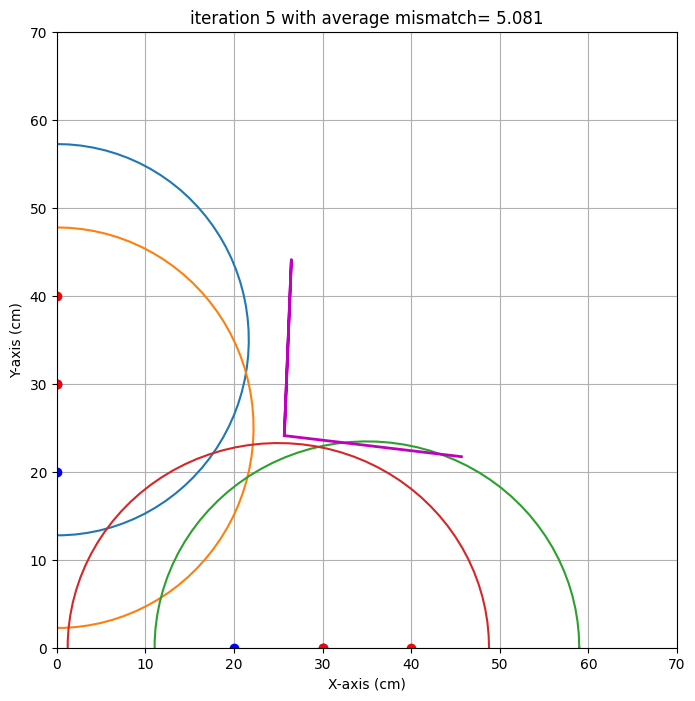

end iteration 5 with average mismatch= 5.081


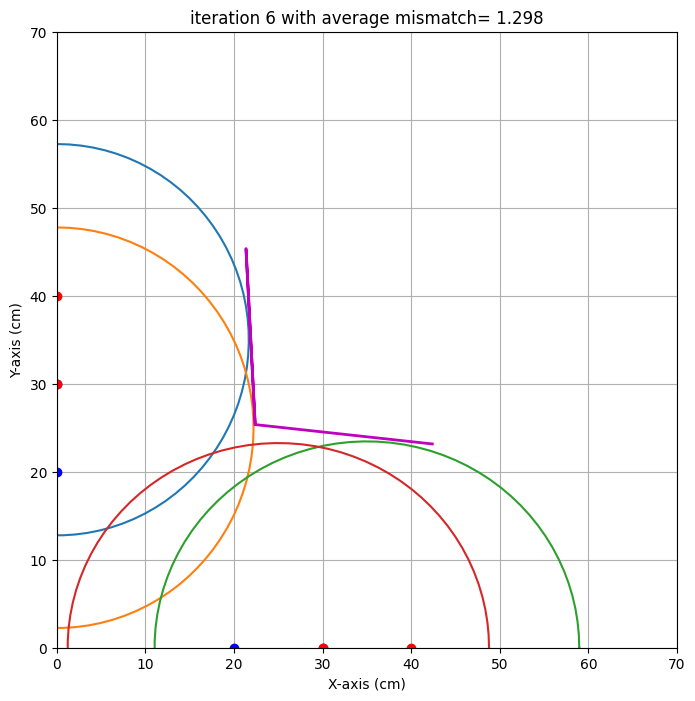

end iteration 6 with average mismatch= 1.298


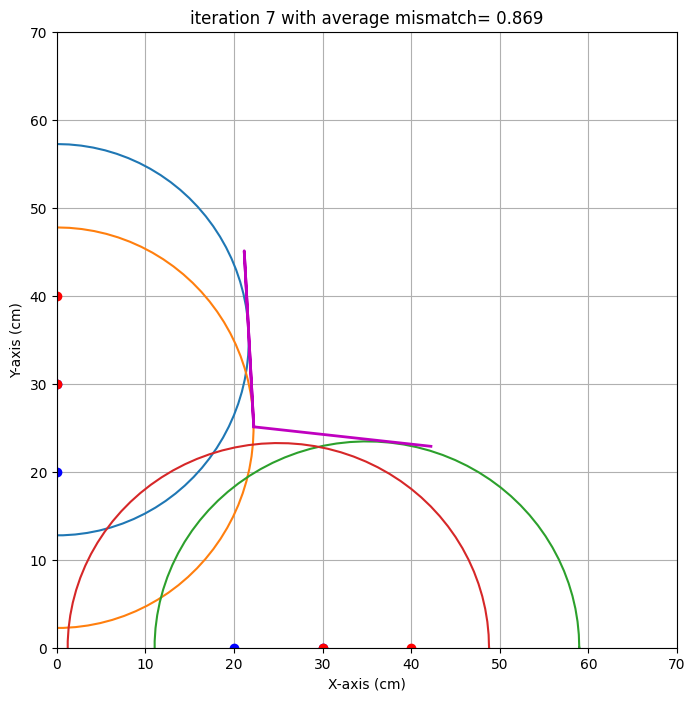

end iteration 7 with average mismatch= 0.869
end iteration 8 with average mismatch= 0.869


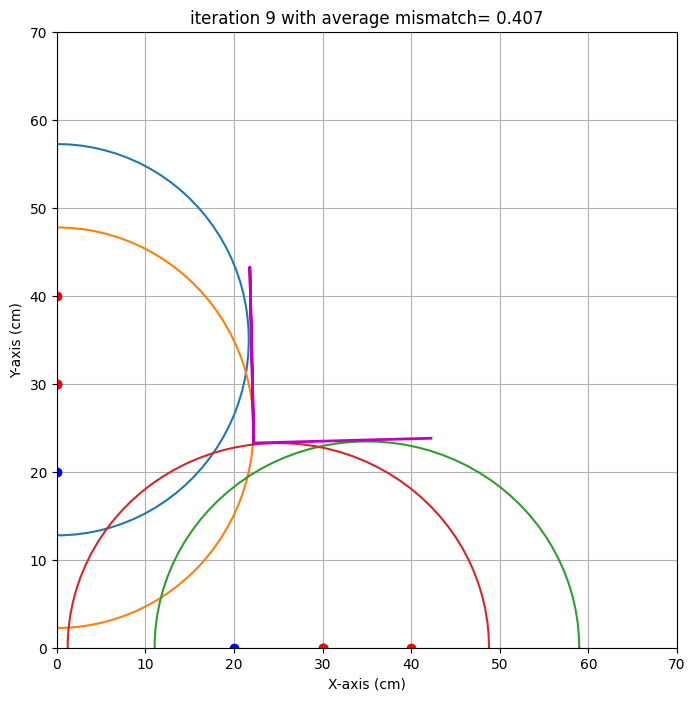

end iteration 9 with average mismatch= 0.407
end iteration 10 with average mismatch= 0.368
end iteration 11 with average mismatch= 0.349
end iteration 12 with average mismatch= 0.344


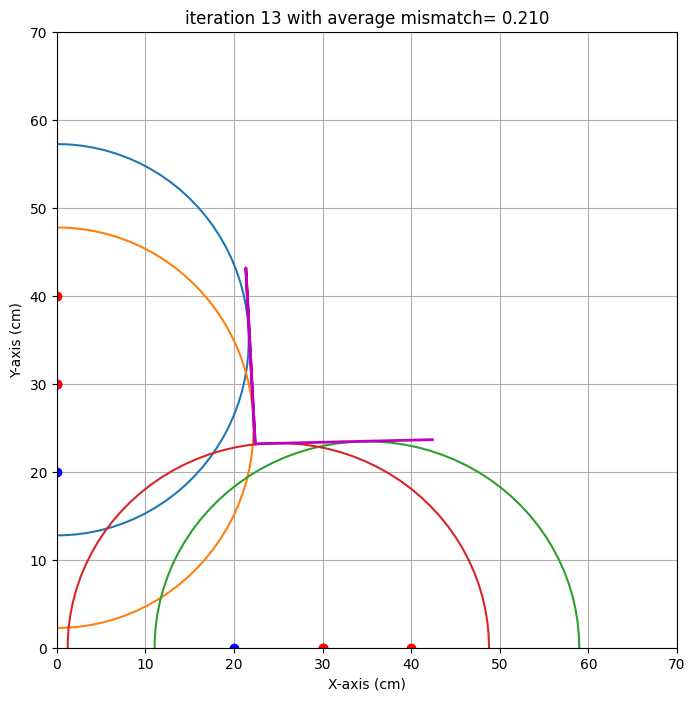

end iteration 13 with average mismatch= 0.210


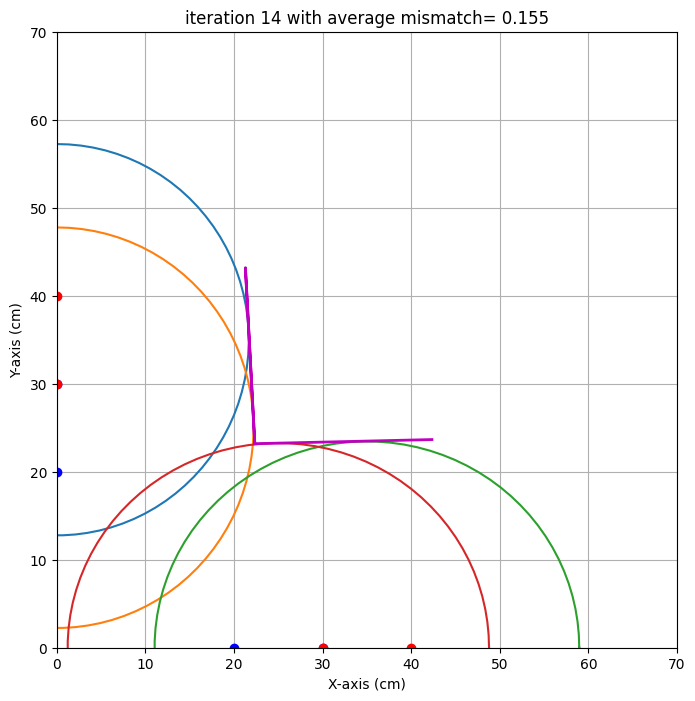

end iteration 14 with average mismatch= 0.155
end iteration 15 with average mismatch= 0.149
end iteration 16 with average mismatch= 0.149
end iteration 17 with average mismatch= 0.149
end iteration 18 with average mismatch= 0.149
end iteration 19 with average mismatch= 0.149
end iteration 20 with average mismatch= 0.149
end iteration 21 with average mismatch= 0.149
end iteration 22 with average mismatch= 0.149
end iteration 23 with average mismatch= 0.149
end iteration 24 with average mismatch= 0.149
end iteration 25 with average mismatch= 0.149
end iteration 26 with average mismatch= 0.149
end iteration 27 with average mismatch= 0.149
end iteration 28 with average mismatch= 0.149
end iteration 29 with average mismatch= 0.149
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.149
###########################################################

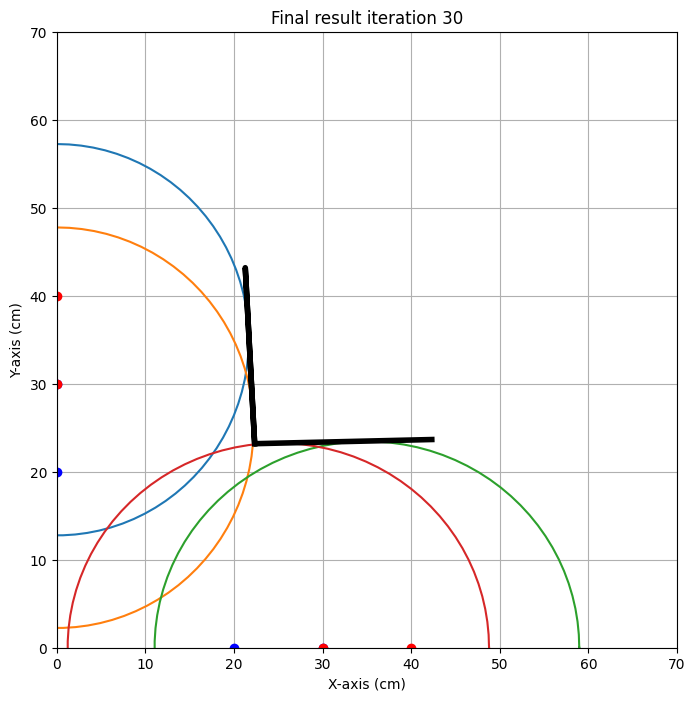

In [19]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,44.47],
    [0,30,0,20,45.52],
    #[0,10,0,20,193.37],
    [40,0,30,0,47.95],
    [30,0,20,0,47.58],
    #[10,0,20,0,190.56],
    #[10,0,0,10,191.41]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [20]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 22.3 cm met een standaardafwijking van 0.0 cm 
y0: 23.2 cm met een standaardafwijking van 0.0 cm 
alpha: 1.4 graden met een standaardafwijking van 0.0 graad 
beta: -3.0 graden met een standaardafwijking van 0.0 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Hugo Rutten]

Voeg een foto in van het algoritme van het eerste groepslid

<img src="SchemaHugo.jpeg" width="400">

#### algoritme [Yael Jawahierkhan]

Voeg een foto in van het algoritme van het tweede groepslid

<img src="SchemaYael.jpeg" width="400">

#### algoritme [Matteo Leonardi]

Voeg een foto in van het algoritme van het derde groepslid

<img src="SchemaMatteo.jpeg" width="400">

In [21]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [22]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 24,   
           'y0': 31,
           'alpha': 25,  
           'beta': 10,  
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Yael Jawahierkhan' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
  [62.4,0,52.5,0,83.5],
    [0,62.5,0,52.5,65.2],
    #[0,70,0,60,200],
    #[70,0,60,0,200],

    ]),
       'Matteo Leonardi' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
  [70,0,50,0,87.8],
    [60,0,40,0,79.6],
    [60,0,50,0,81.5],
    [0,70,0,50,67.9],  
    [0,60,0,40,63.6],
    [0,60,0,50,63.2],
    ])}

## Opdracht 7: Evaluatie.

Yael Jawahierkhan
Running the imaging algorithm with the following data:
     xs    ys    xr    yr     R
0  62.4   0.0  52.5   0.0  83.5
1   0.0  62.5   0.0  52.5  65.2


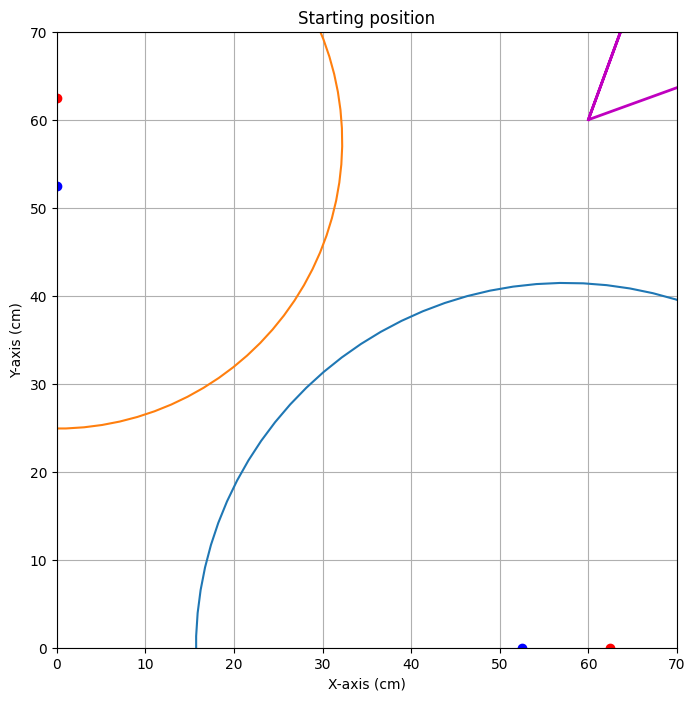


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=51.706


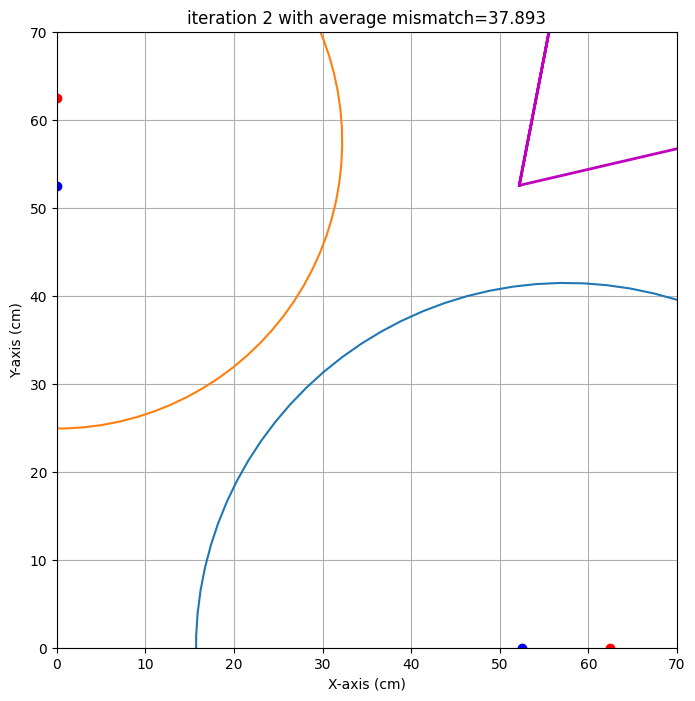

end iteration 2 with average mismatch=37.893


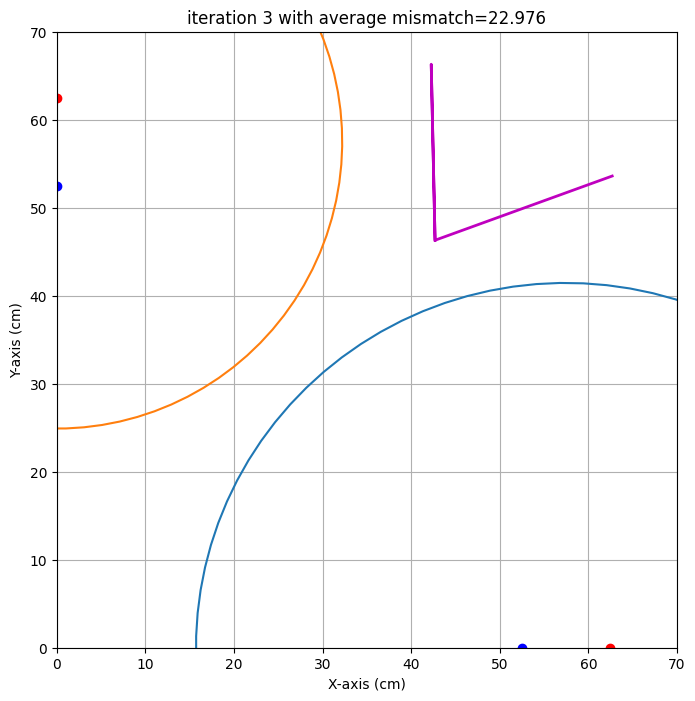

end iteration 3 with average mismatch=22.976


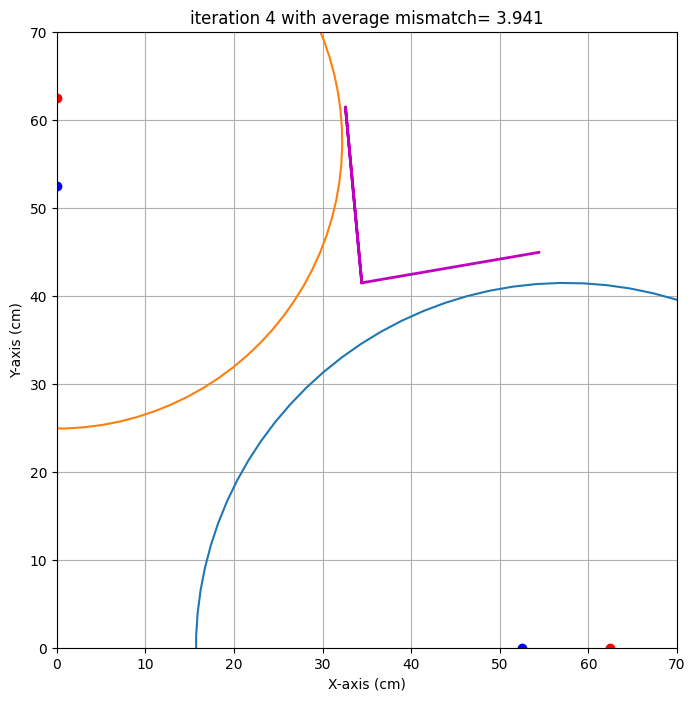

end iteration 4 with average mismatch= 3.941


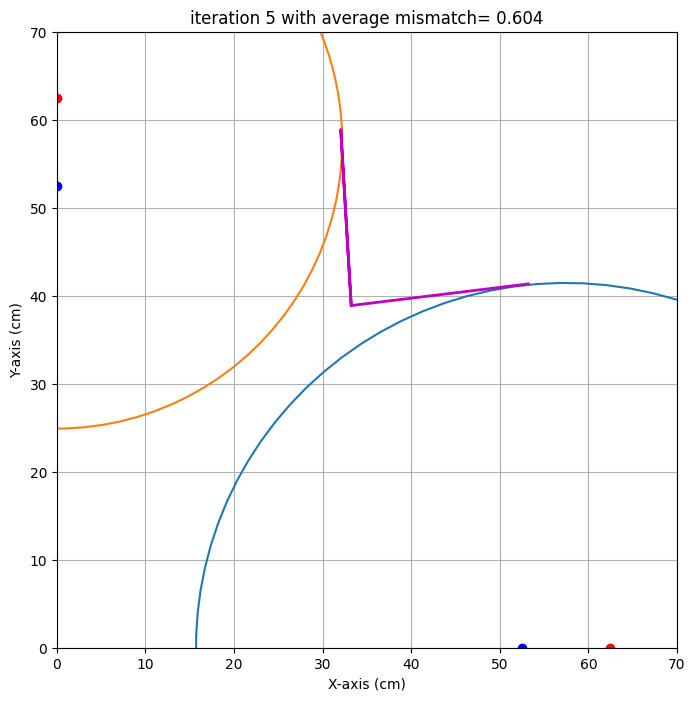

end iteration 5 with average mismatch= 0.604


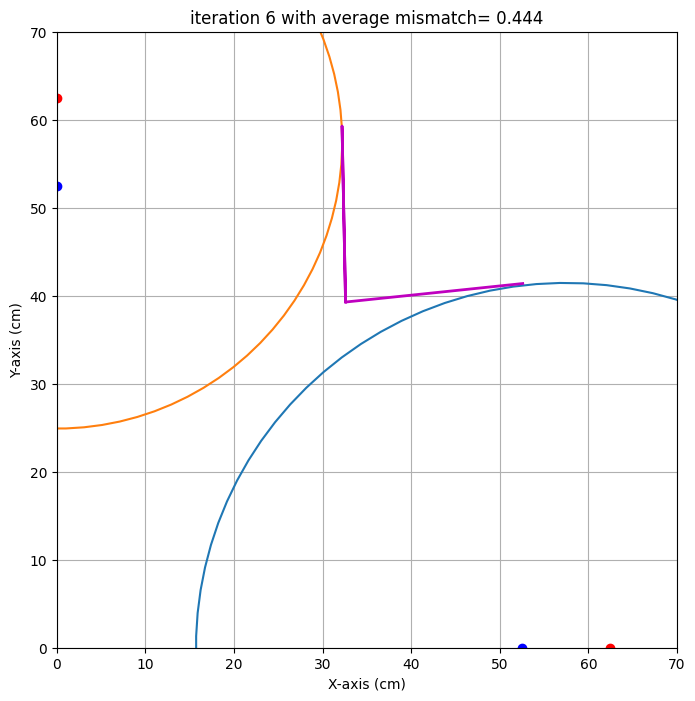

end iteration 6 with average mismatch= 0.444
end iteration 7 with average mismatch= 0.427
end iteration 8 with average mismatch= 0.426


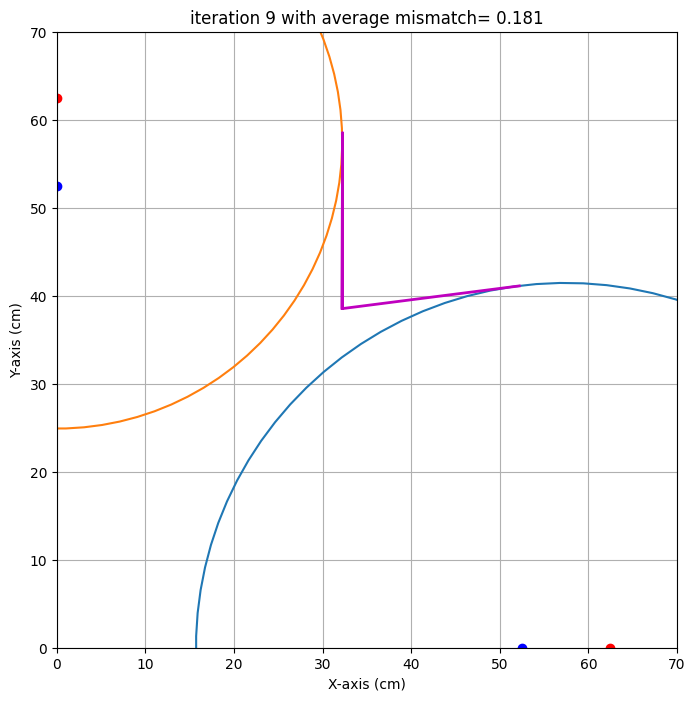

end iteration 9 with average mismatch= 0.181
end iteration 10 with average mismatch= 0.167
end iteration 11 with average mismatch= 0.163
end iteration 12 with average mismatch= 0.163
end iteration 13 with average mismatch= 0.163
end iteration 14 with average mismatch= 0.163
end iteration 15 with average mismatch= 0.163
end iteration 16 with average mismatch= 0.163
end iteration 17 with average mismatch= 0.163
end iteration 18 with average mismatch= 0.163
end iteration 19 with average mismatch= 0.163
end iteration 20 with average mismatch= 0.163
end iteration 21 with average mismatch= 0.163
end iteration 22 with average mismatch= 0.163
end iteration 23 with average mismatch= 0.163
end iteration 24 with average mismatch= 0.163
end iteration 25 with average mismatch= 0.163
end iteration 26 with average mismatch= 0.163
end iteration 27 with average mismatch= 0.163
end iteration 28 with average mismatch= 0.163
end iteration 29 with average mismatch= 0.163
Last iteration, also determine unce

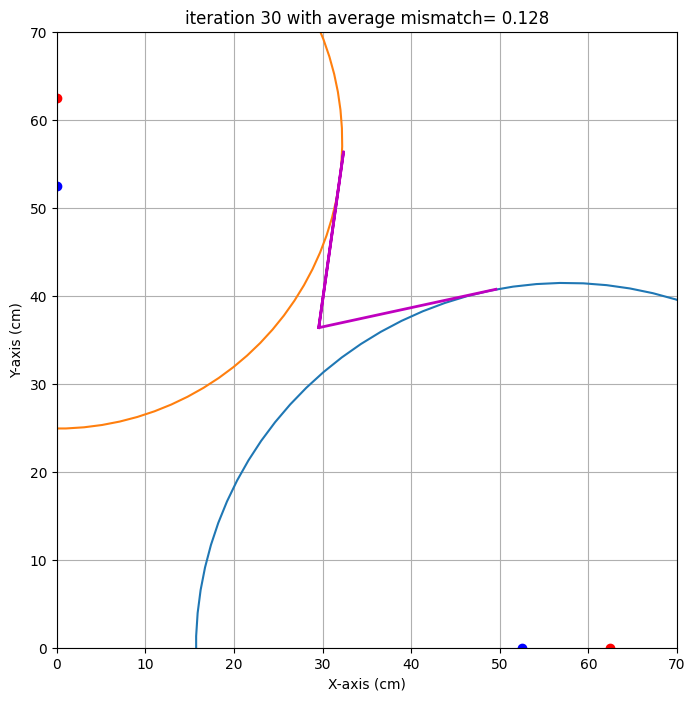

end iteration 30 with average mismatch= 0.128
###############################################################################
end of iteration  30
Best alpha=  12.31 with uncertainty=  13.79
Best beta =   7.97 with uncertainty=   9.46
Best x0   =  29.56 with uncertainty=   3.62
Best y0   =  36.37 with uncertainty=   4.77
###############################################################################


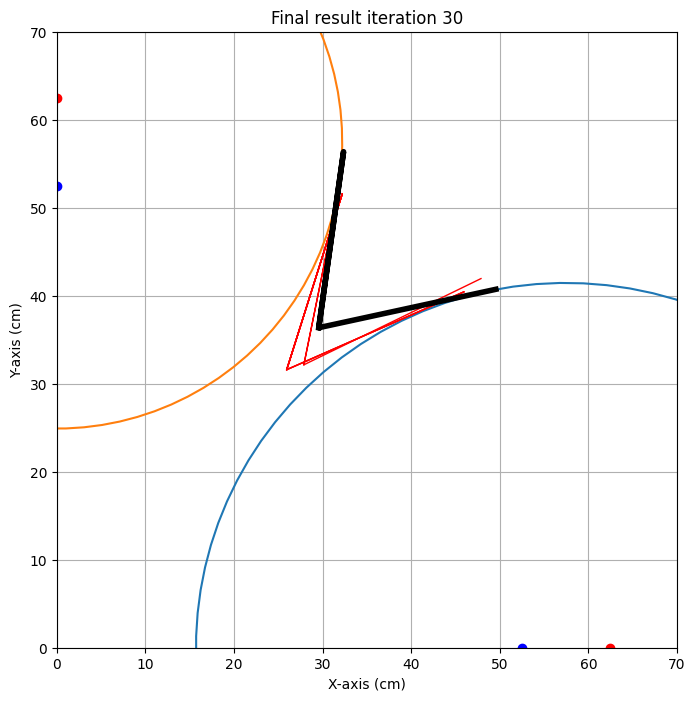

{'alpha': np.float64(12.307814769835343), 'alpha_eps': np.float64(13.793724264427748), 'beta': np.float64(7.974886108745119), 'beta_eps': np.float64(9.457840535933043), 'x0': np.float64(29.562646989112242), 'x0_eps': np.float64(3.617426707756646), 'y0': np.float64(36.36650632750674), 'y0_eps': np.float64(4.7696378954098115)}
Matteo Leonardi
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  70   0  50   0  87.8
1  60   0  40   0  79.6
2  60   0  50   0  81.5
3   0  70   0  50  67.9
4   0  60   0  40  63.6
5   0  60   0  50  63.2


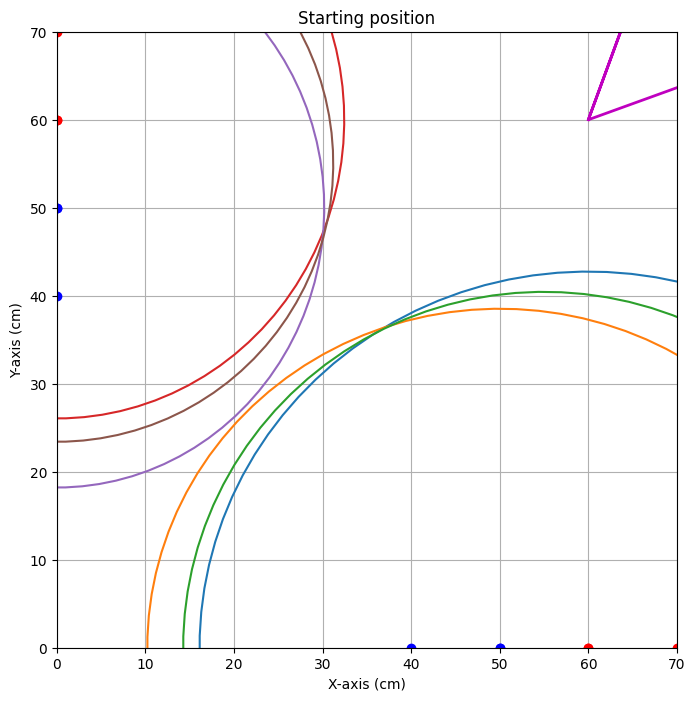


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=53.671


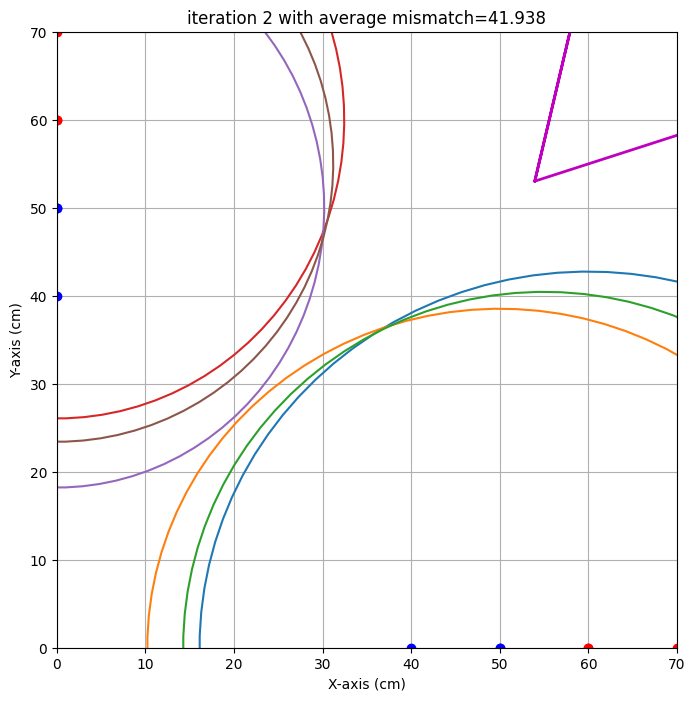

end iteration 2 with average mismatch=41.938


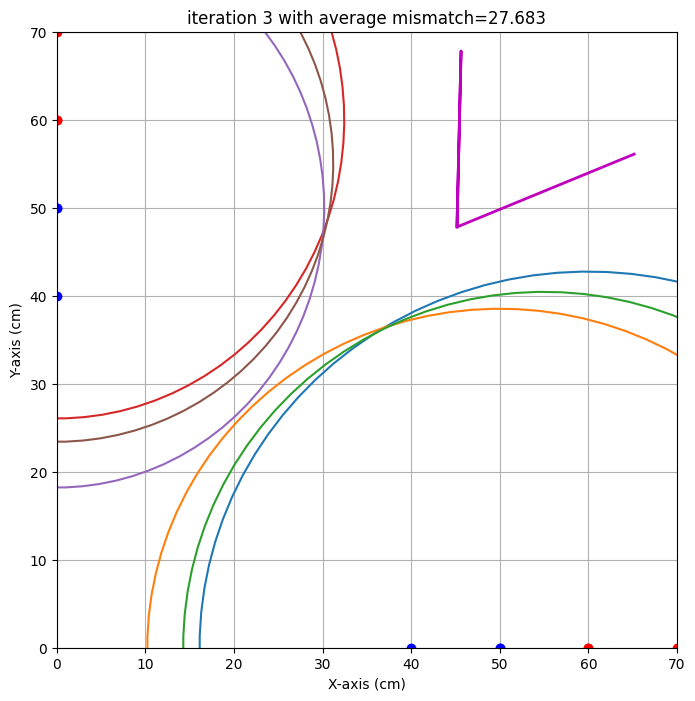

end iteration 3 with average mismatch=27.683


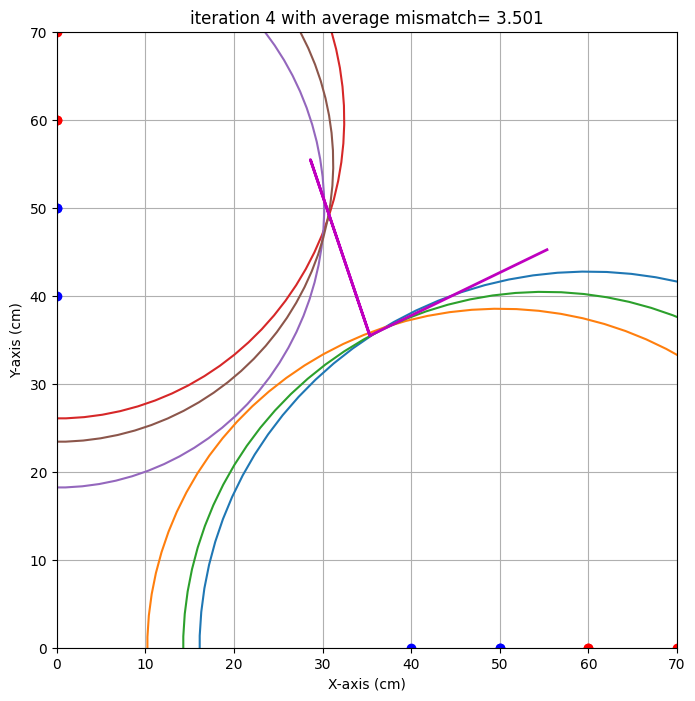

end iteration 4 with average mismatch= 3.501


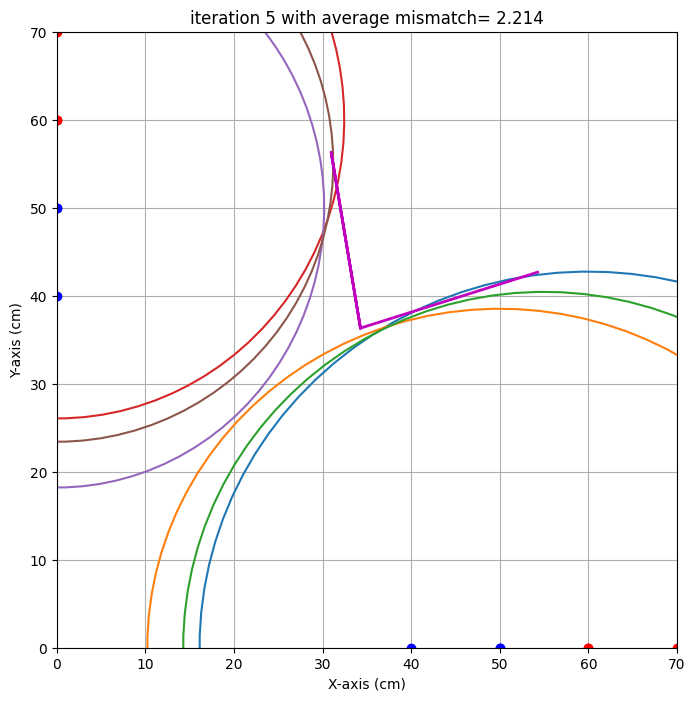

end iteration 5 with average mismatch= 2.214


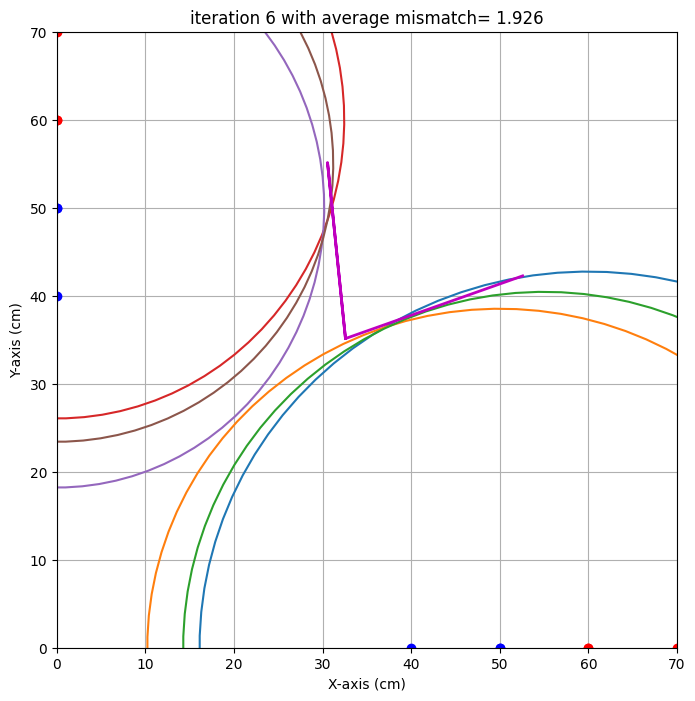

end iteration 6 with average mismatch= 1.926


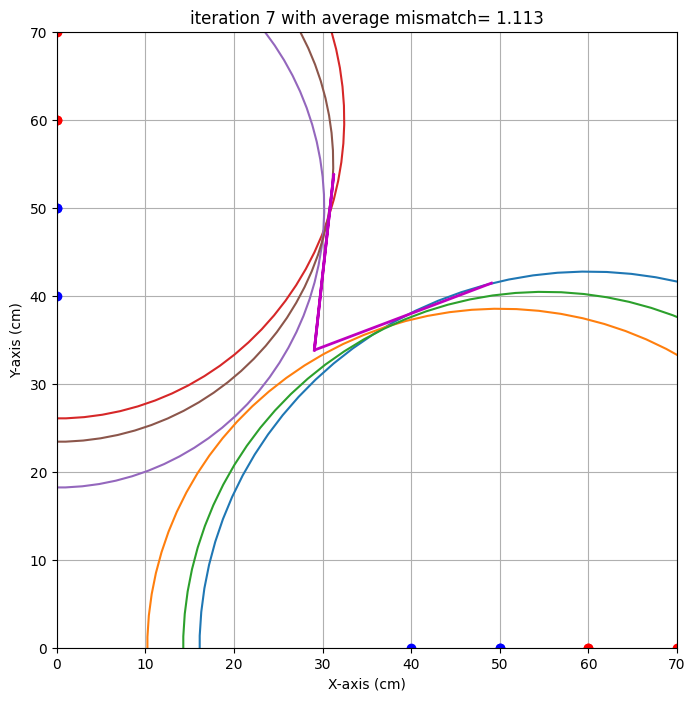

end iteration 7 with average mismatch= 1.113


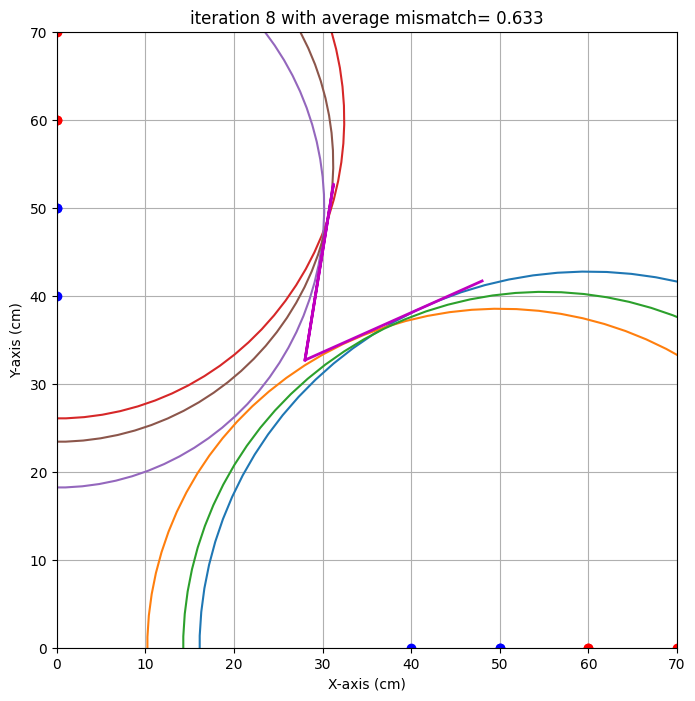

end iteration 8 with average mismatch= 0.633
end iteration 9 with average mismatch= 0.632
end iteration 10 with average mismatch= 0.625
end iteration 11 with average mismatch= 0.625


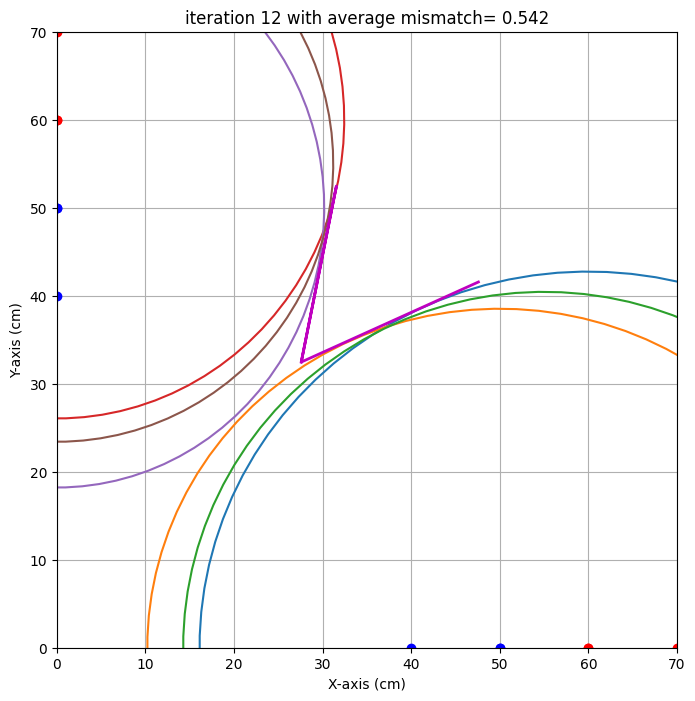

end iteration 12 with average mismatch= 0.542
end iteration 13 with average mismatch= 0.535
end iteration 14 with average mismatch= 0.511
end iteration 15 with average mismatch= 0.506
end iteration 16 with average mismatch= 0.505
end iteration 17 with average mismatch= 0.505
end iteration 18 with average mismatch= 0.505
end iteration 19 with average mismatch= 0.505
end iteration 20 with average mismatch= 0.505
end iteration 21 with average mismatch= 0.505
end iteration 22 with average mismatch= 0.505
end iteration 23 with average mismatch= 0.505
end iteration 24 with average mismatch= 0.464
end iteration 25 with average mismatch= 0.462
end iteration 26 with average mismatch= 0.461
end iteration 27 with average mismatch= 0.460
end iteration 28 with average mismatch= 0.453
end iteration 29 with average mismatch= 0.443
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.442
#################

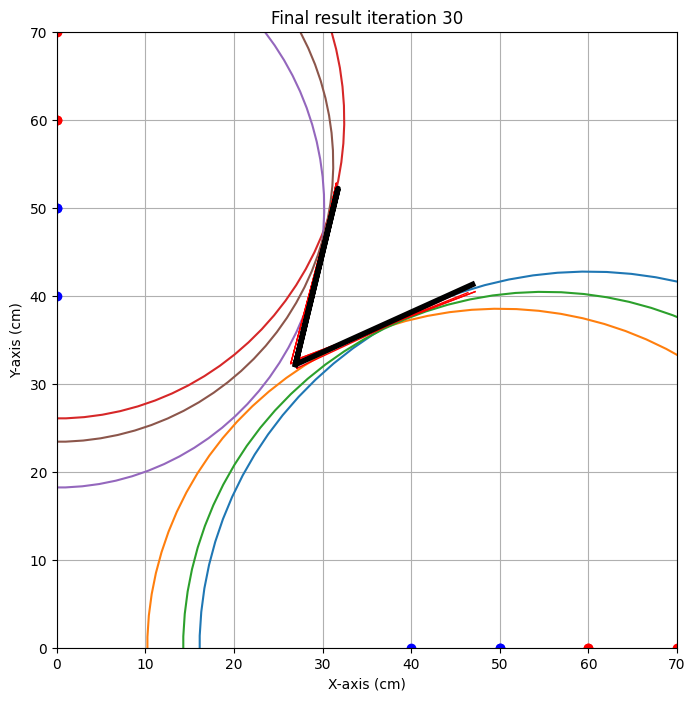

{'alpha': np.float64(24.475191151043937), 'alpha_eps': np.float64(3.5406813187048947), 'beta': np.float64(13.528857849781527), 'beta_eps': np.float64(1.567758326447926), 'x0': np.float64(26.928148042639616), 'x0_eps': np.float64(0.5261196362506908), 'y0': np.float64(32.177025749280475), 'y0_eps': np.float64(0.6277029504495175)}


In [23]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [24]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Yael Jawahierkhan 
x0 target is : 24.0. Gevonden waarde: 29.6 cm met een standaardafwijking van 3.6 cm 
y0 target is : 31.0. Gevonden waarde: 36.4 cm met een standaardafwijking van 4.8 cm 
alpha target is : 25.0. Gevonden waarde: 12.3 graden met een standaardafwijking van 13.8 graad 
beta target is : 10.0. Gevonden waarde: 8.0 graden met een standaardafwijking van 9.5 graad 

Matteo Leonardi 
x0 target is : 24.0. Gevonden waarde: 26.9 cm met een standaardafwijking van 0.5 cm 
y0 target is : 31.0. Gevonden waarde: 32.2 cm met een standaardafwijking van 0.6 cm 
alpha target is : 25.0. Gevonden waarde: 24.5 graden met een standaardafwijking van 3.5 graad 
beta target is : 10.0. Gevonden waarde: 13.5 graden met een standaardafwijking van 1.6 graad 



## Opdracht 8: Iteratie1+. 14:49.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: 

![Alt](Iteratie1.jpeg)


In [25]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  70   0  50   0  87.8
1  60   0  40   0  79.6
2  60   0  50   0  81.5
3   0  70   0  50  67.9
4   0  60   0  40  63.6
5   0  60   0  50  63.2
6  70   0  40   0  84.4
7   0  70   0  40  68.7


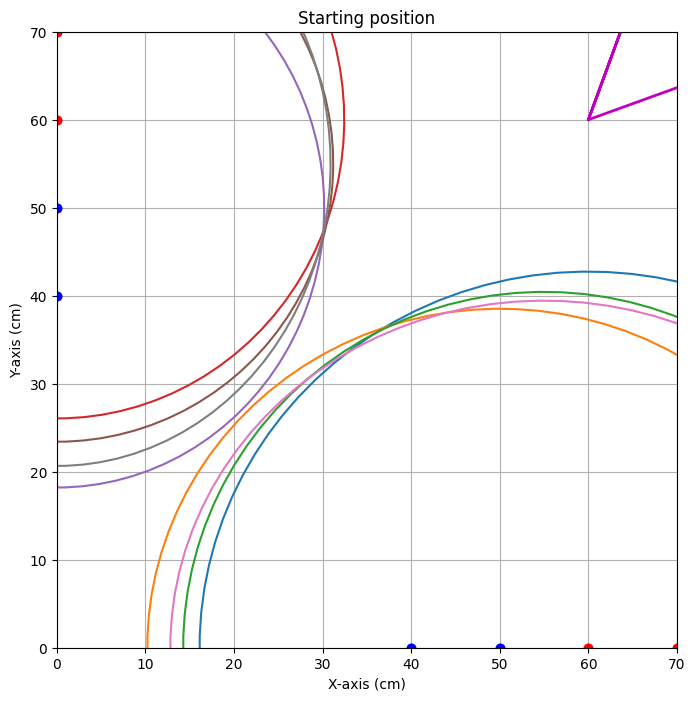


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=53.529


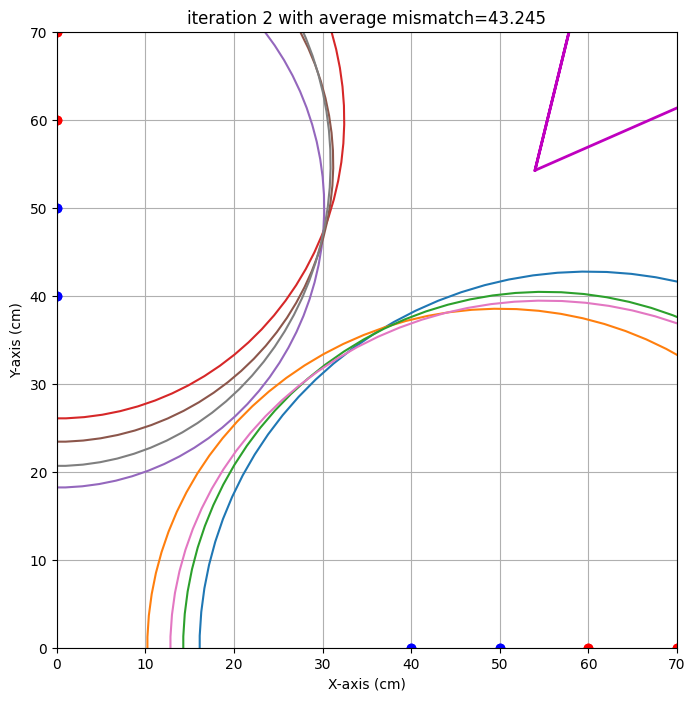

end iteration 2 with average mismatch=43.245


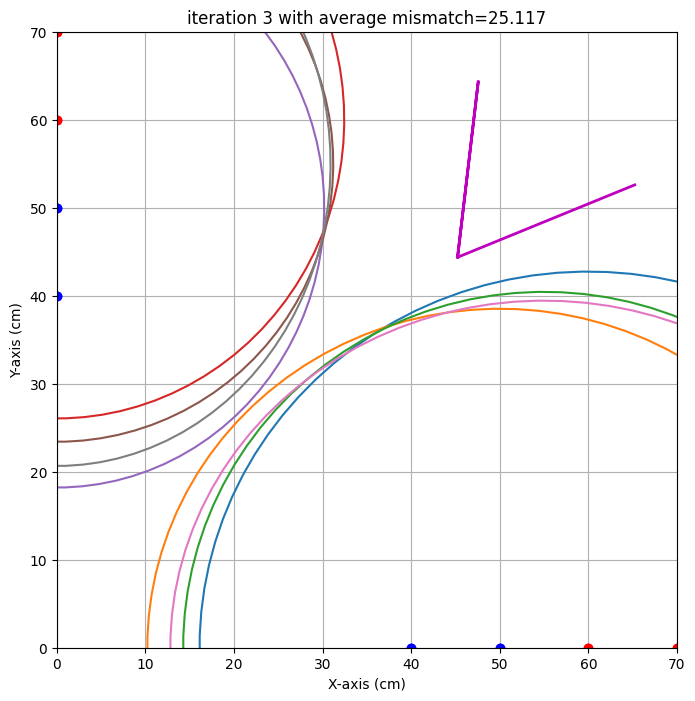

end iteration 3 with average mismatch=25.117


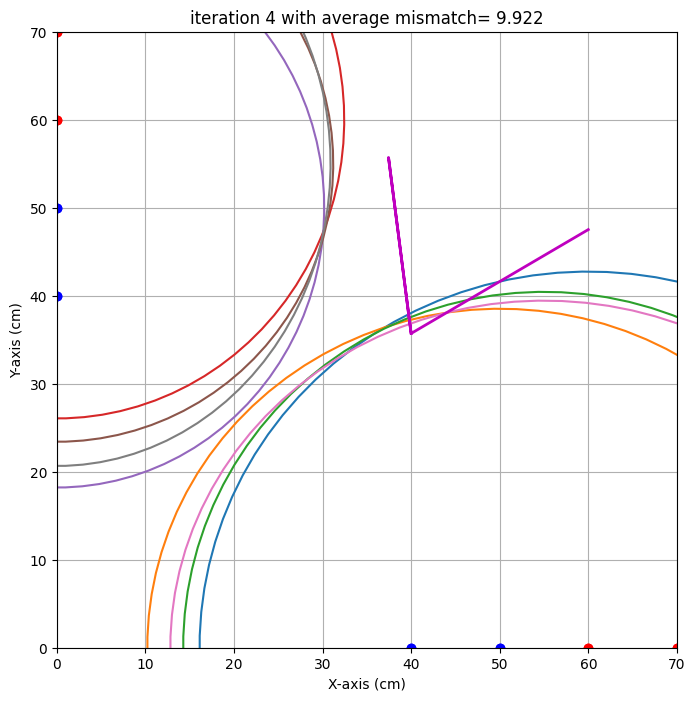

end iteration 4 with average mismatch= 9.922


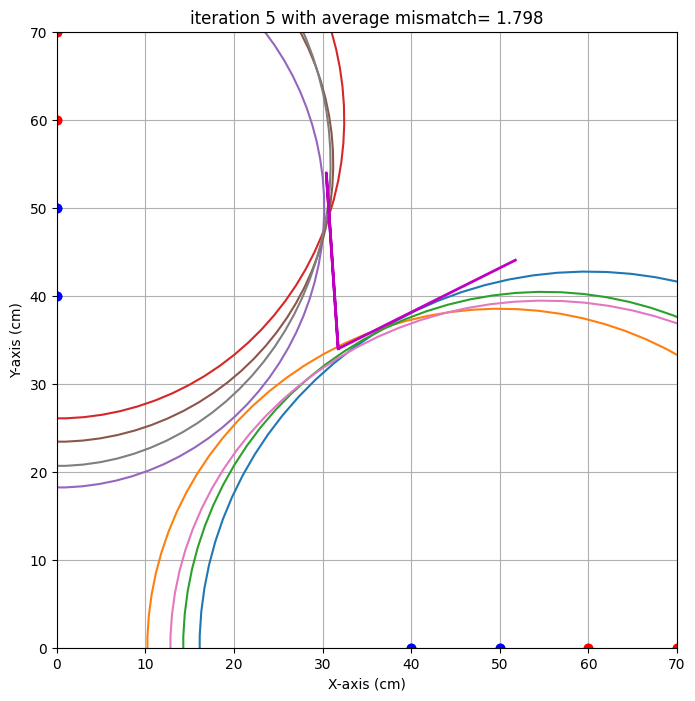

end iteration 5 with average mismatch= 1.798


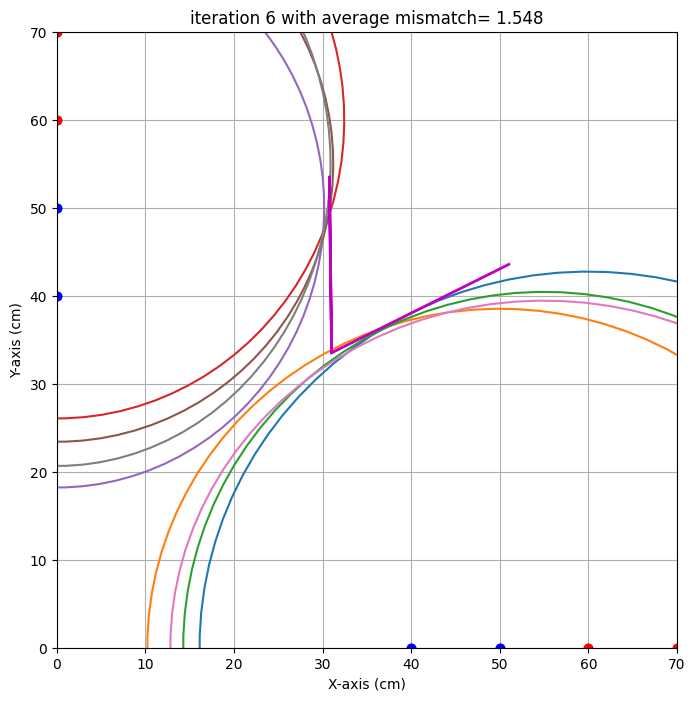

end iteration 6 with average mismatch= 1.548


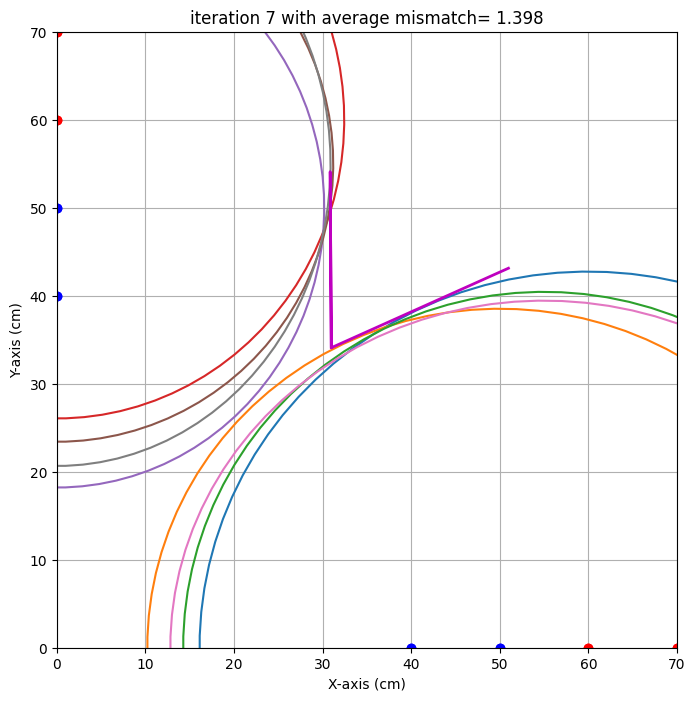

end iteration 7 with average mismatch= 1.398
end iteration 8 with average mismatch= 1.396


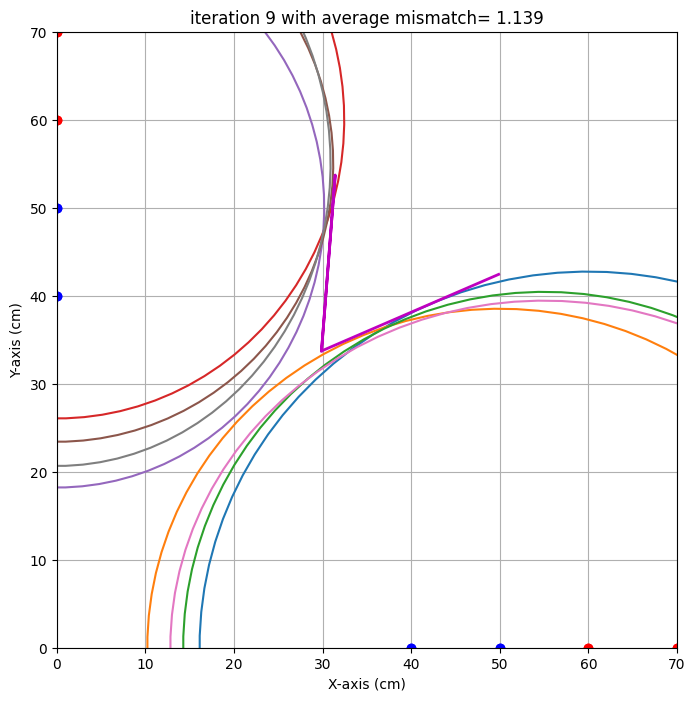

end iteration 9 with average mismatch= 1.139
end iteration 10 with average mismatch= 1.042


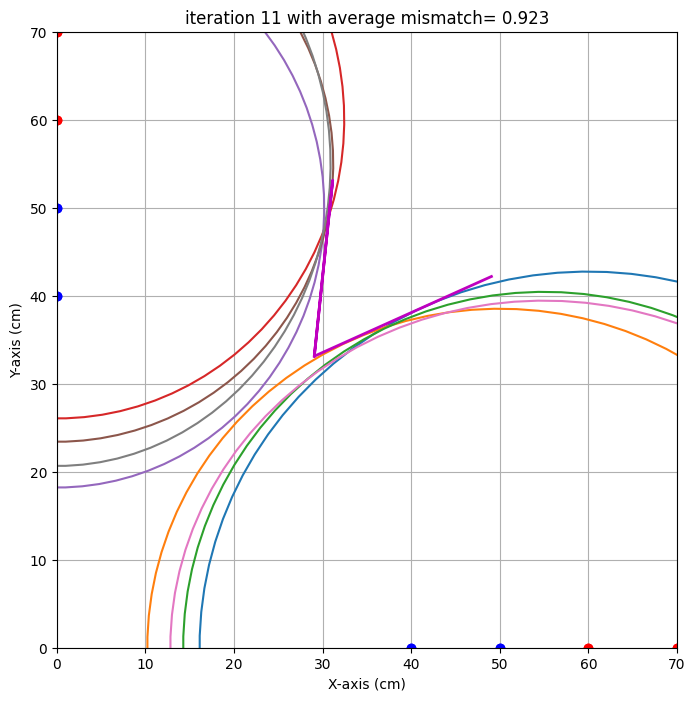

end iteration 11 with average mismatch= 0.923
end iteration 12 with average mismatch= 0.859


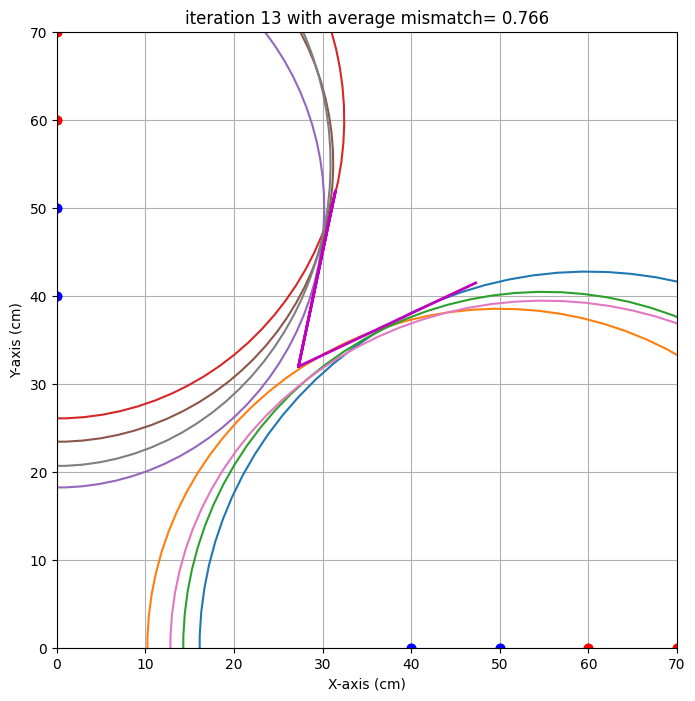

end iteration 13 with average mismatch= 0.766


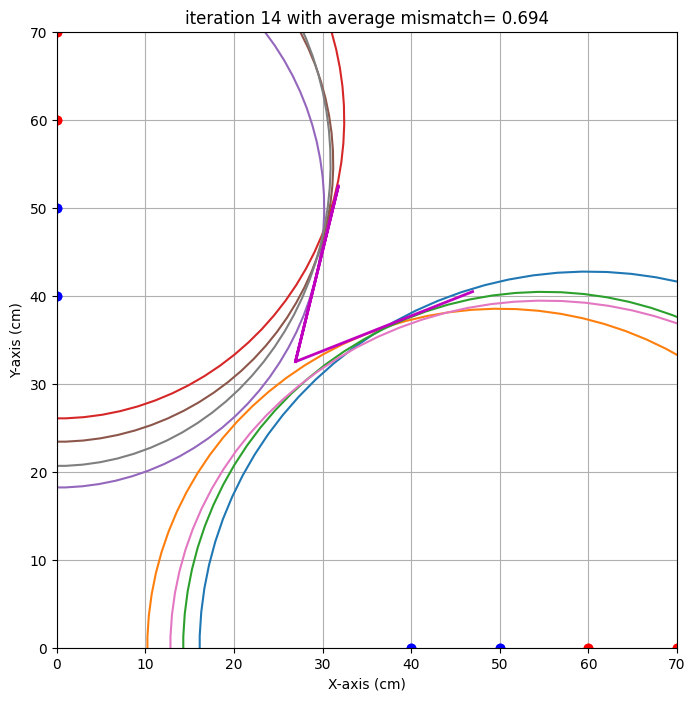

end iteration 14 with average mismatch= 0.694
end iteration 15 with average mismatch= 0.652
end iteration 16 with average mismatch= 0.652
end iteration 17 with average mismatch= 0.652
end iteration 18 with average mismatch= 0.652
end iteration 19 with average mismatch= 0.652
end iteration 20 with average mismatch= 0.652
end iteration 21 with average mismatch= 0.652
end iteration 22 with average mismatch= 0.652
end iteration 23 with average mismatch= 0.652
end iteration 24 with average mismatch= 0.652
end iteration 25 with average mismatch= 0.652
end iteration 26 with average mismatch= 0.652
end iteration 27 with average mismatch= 0.650
end iteration 28 with average mismatch= 0.647
end iteration 29 with average mismatch= 0.647
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.647
###############################################################################
end of iteration  30
Best alp

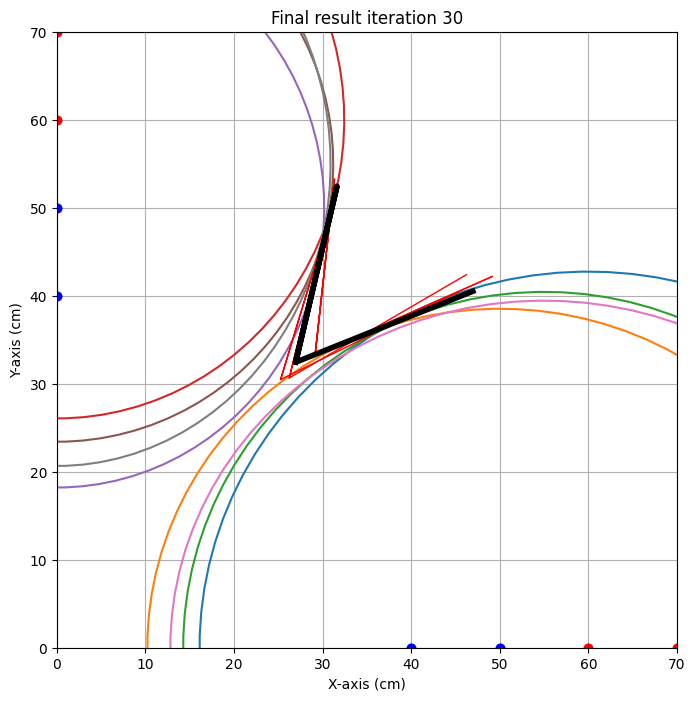

{'alpha': np.float64(21.946133684331986), 'alpha_eps': np.float64(8.449674341501268), 'beta': np.float64(13.110688399114709), 'beta_eps': np.float64(6.861983933301671), 'x0': np.float64(26.9624964264707), 'x0_eps': np.float64(2.1861800731545706), 'y0': np.float64(32.44833958044575), 'y0_eps': np.float64(1.970376726088805)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  70   0  50   0  72.2
1  60   0  40   0  70.6
2  60   0  50   0  69.0
3   0  70   0  50  94.5
4   0  60   0  40  93.5
5   0  60   0  50  90.4
6  70   0  40   0  75.4
7   0  70   0  40  93.4


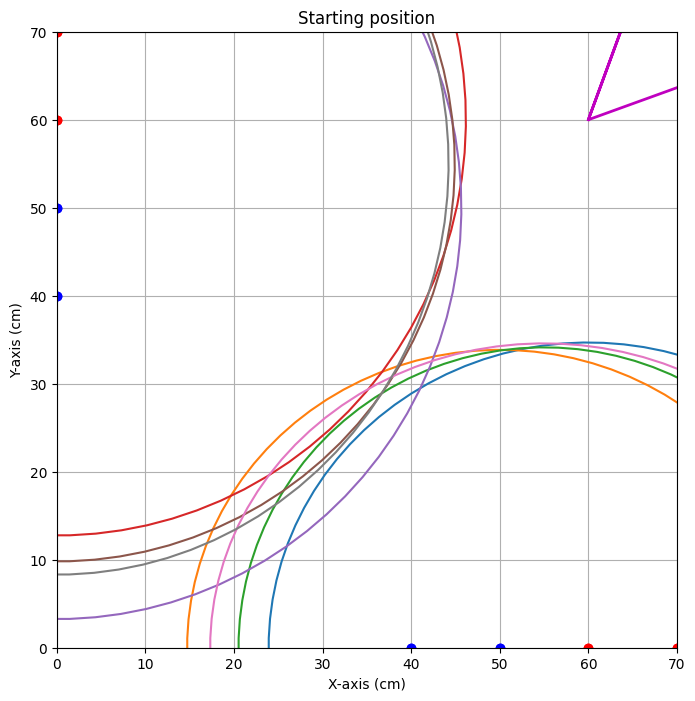


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=45.741


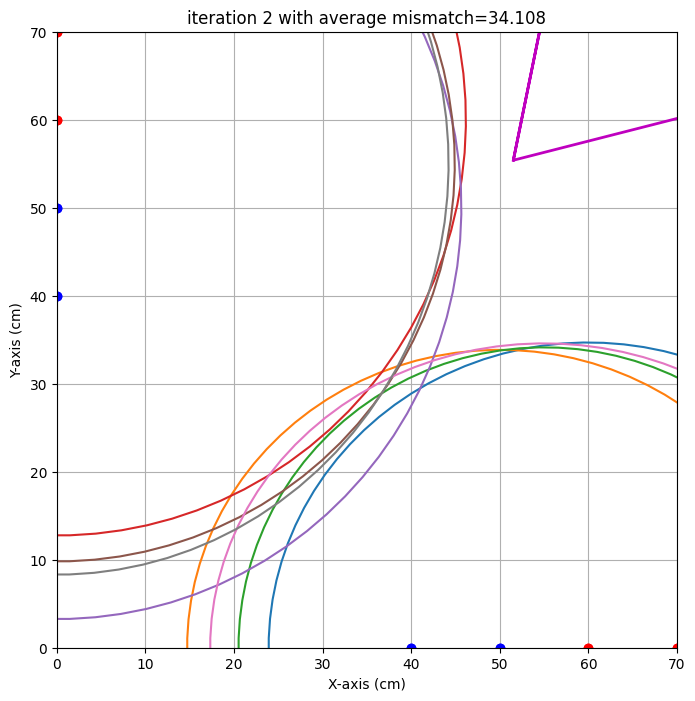

end iteration 2 with average mismatch=34.108


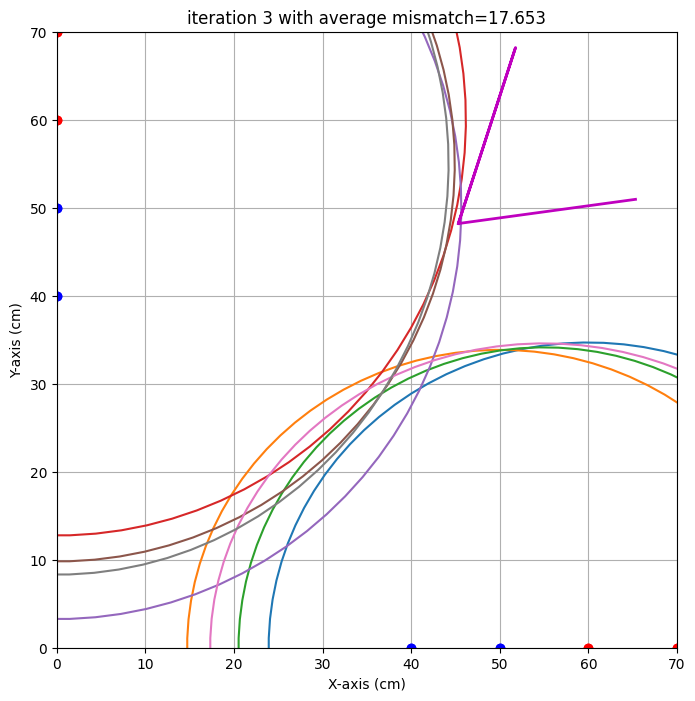

end iteration 3 with average mismatch=17.653


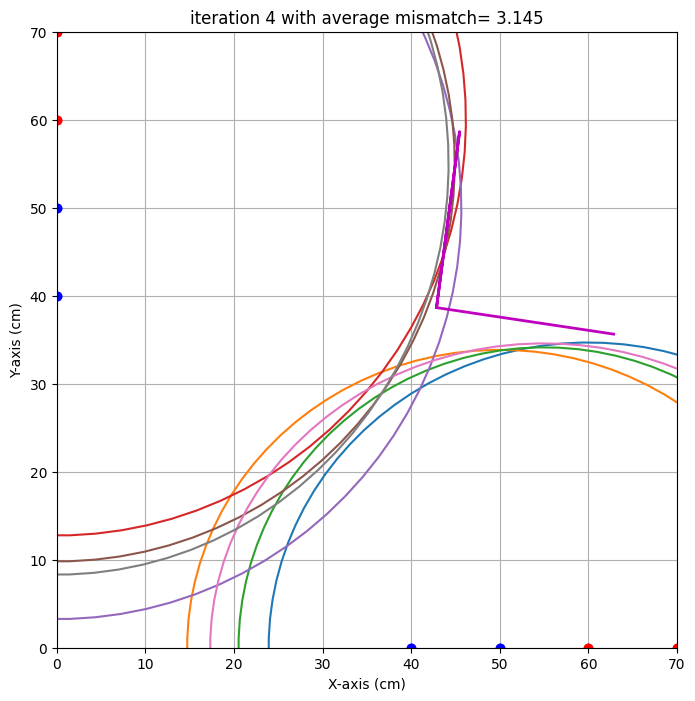

end iteration 4 with average mismatch= 3.145


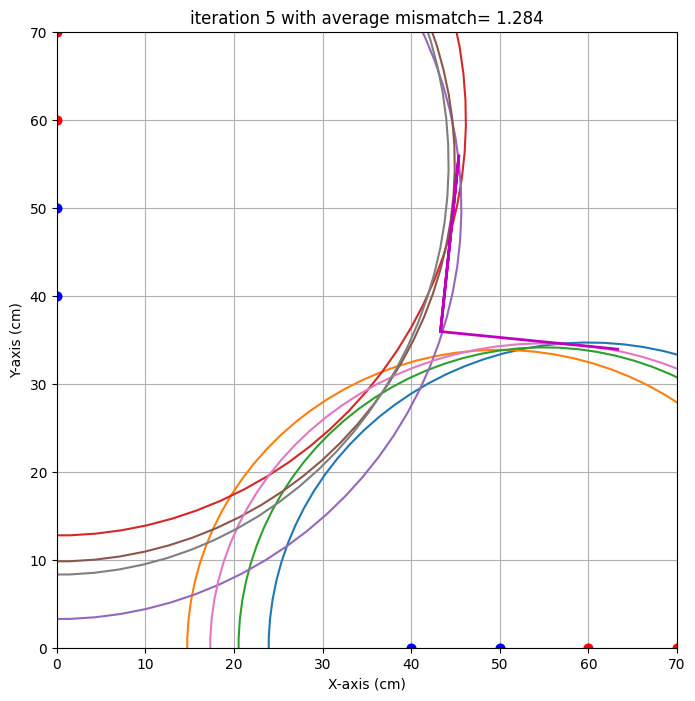

end iteration 5 with average mismatch= 1.284
end iteration 6 with average mismatch= 1.227
end iteration 7 with average mismatch= 1.162


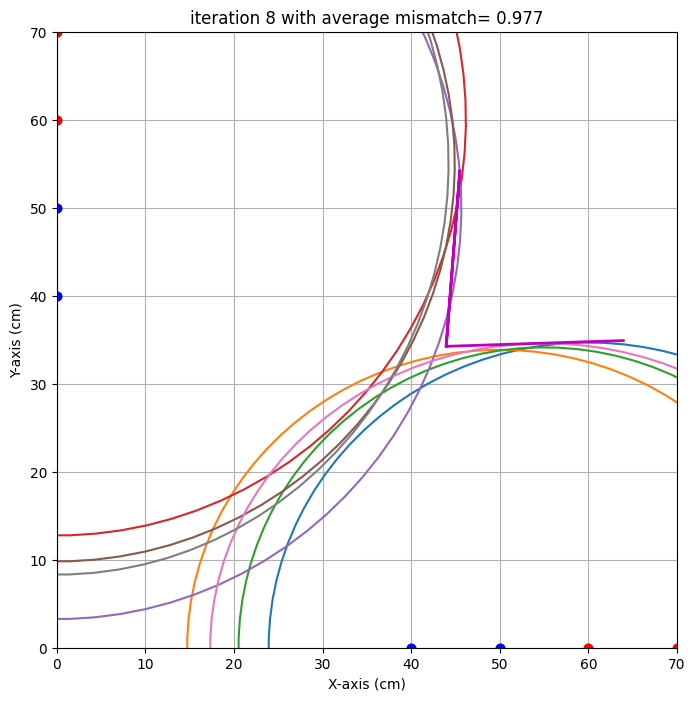

end iteration 8 with average mismatch= 0.977


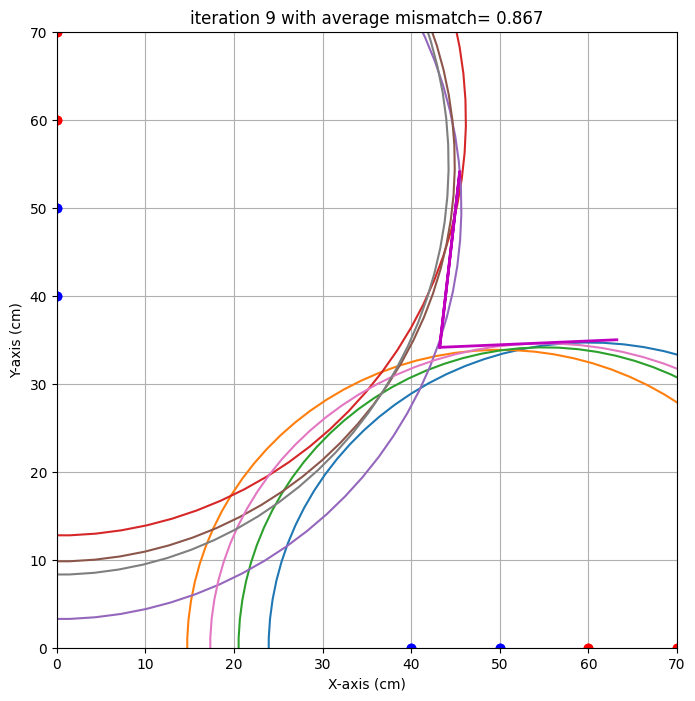

end iteration 9 with average mismatch= 0.867
end iteration 10 with average mismatch= 0.816


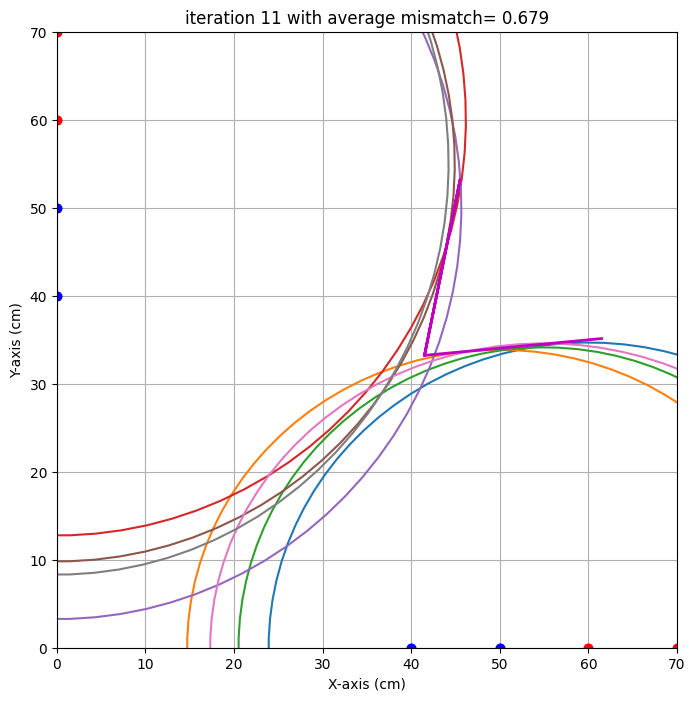

end iteration 11 with average mismatch= 0.679
end iteration 12 with average mismatch= 0.666
end iteration 13 with average mismatch= 0.655
end iteration 14 with average mismatch= 0.655
end iteration 15 with average mismatch= 0.654
end iteration 16 with average mismatch= 0.654
end iteration 17 with average mismatch= 0.654
end iteration 18 with average mismatch= 0.654
end iteration 19 with average mismatch= 0.654
end iteration 20 with average mismatch= 0.654
end iteration 21 with average mismatch= 0.654
end iteration 22 with average mismatch= 0.654
end iteration 23 with average mismatch= 0.654
end iteration 24 with average mismatch= 0.654
end iteration 25 with average mismatch= 0.654
end iteration 26 with average mismatch= 0.654
end iteration 27 with average mismatch= 0.654
end iteration 28 with average mismatch= 0.654
end iteration 29 with average mismatch= 0.654
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 

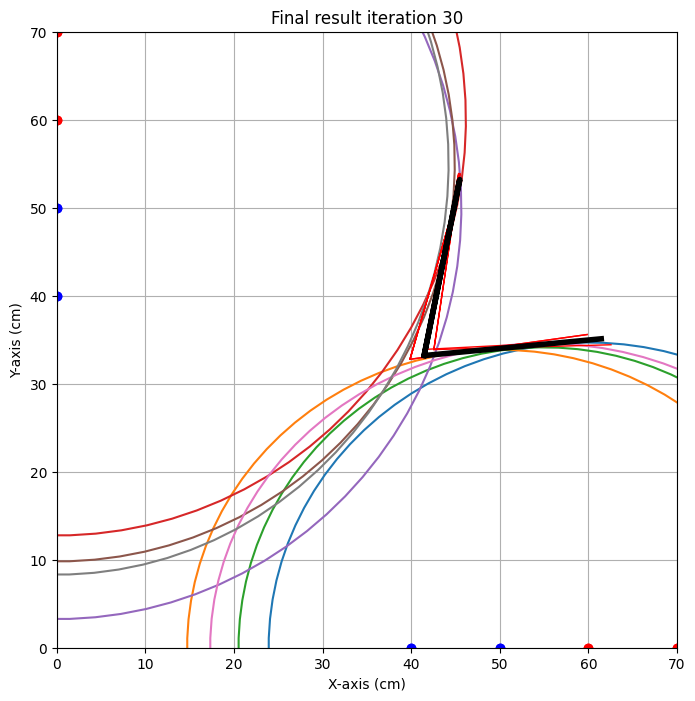

{'alpha': np.float64(5.43461841176919), 'alpha_eps': np.float64(3.8683462998543403), 'beta': np.float64(11.378834714224043), 'beta_eps': np.float64(4.560528591146783), 'x0': np.float64(41.45786257417986), 'x0_eps': np.float64(1.59355967711587), 'y0': np.float64(33.20130477643907), 'y0_eps': np.float64(0.7014917723878824)}
locatie 1 
x0 target is : 24.0. Gevonden waarde: 27.0 cm met een standaardafwijking van 2.2 cm 
y0 target is : 31.0. Gevonden waarde: 32.4 cm met een standaardafwijking van 2.0 cm 
alpha target is : 25.0. Gevonden waarde: 21.9 graden met een standaardafwijking van 8.4 graad 
beta target is : 10.0. Gevonden waarde: 13.1 graden met een standaardafwijking van 6.9 graad 

locatie 2 
x0 target is : 37.0. Gevonden waarde: 41.5 cm met een standaardafwijking van 1.6 cm 
y0 target is : 32.9. Gevonden waarde: 33.2 cm met een standaardafwijking van 0.7 cm 
alpha target is : 4.0. Gevonden waarde: 5.4 graden met een standaardafwijking van 3.9 graad 
beta target is : 23.0. Gevonden

In [26]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 24,
                    'y0': 31,
                    'alpha' : 25,
                    'beta' : 10},
           'locatie 2':{'x0': 37 ,
                    'y0': 32.9,
                    'alpha' : 4 ,
                    'beta' : 23 }
            }
           
# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [70,0,50,0,87.8],
    [60,0,40,0,79.6],
    [60,0,50,0,81.5],
    [0,70,0,50,67.9],  
    [0,60,0,40,63.6],
    [0,60,0,50,63.2],
    [70,0,40,0,84.4],
    [0,70,0,40,68.7],
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [70,0,50,0,72.2],
    [60,0,40,0,70.6],
    [60,0,50,0,69.0],
    [0,70,0,50,94.5],  
    [0,60,0,40,93.5],
    [0,60,0,50,90.4],
    [70,0,40,0,75.4],
    [0,70,0,40,93.4],
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

Iteratie 2:

locatie 1
Running the imaging algorithm with the following data:
    xs  ys  xr  yr     R
0   70   0  50   0  88.6
1   70   0  70   0  93.6
2   60   0  50   0  86.5
3   65   0  55   0  88.6
4   70   0  55   0  93.3
5   65   0  50   0  88.3
6    0  70   0  50  75.5
7    0  60   0  40  69.5
8    0  60   0  50  66.8
9    0  70   0  40  74.0
10   0  65   0  45  66.1
11   0  70   0  45  69.8


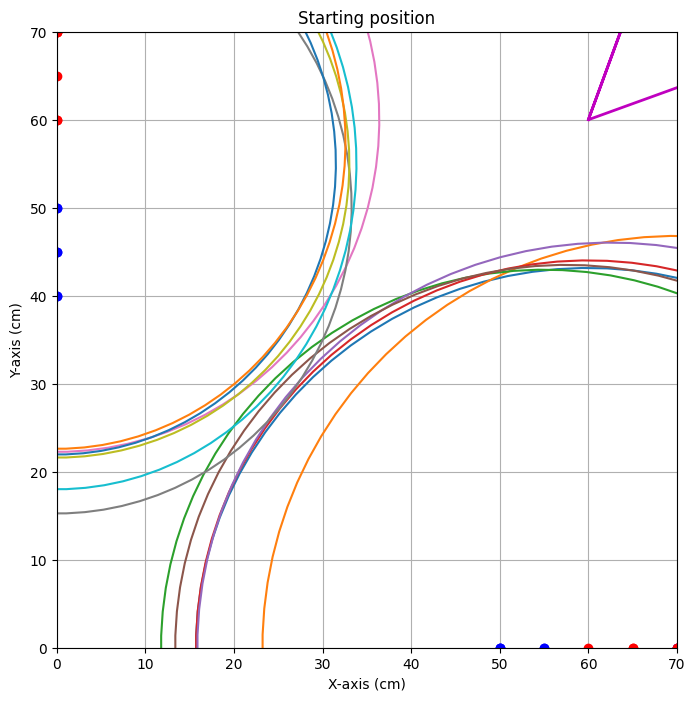


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=47.308


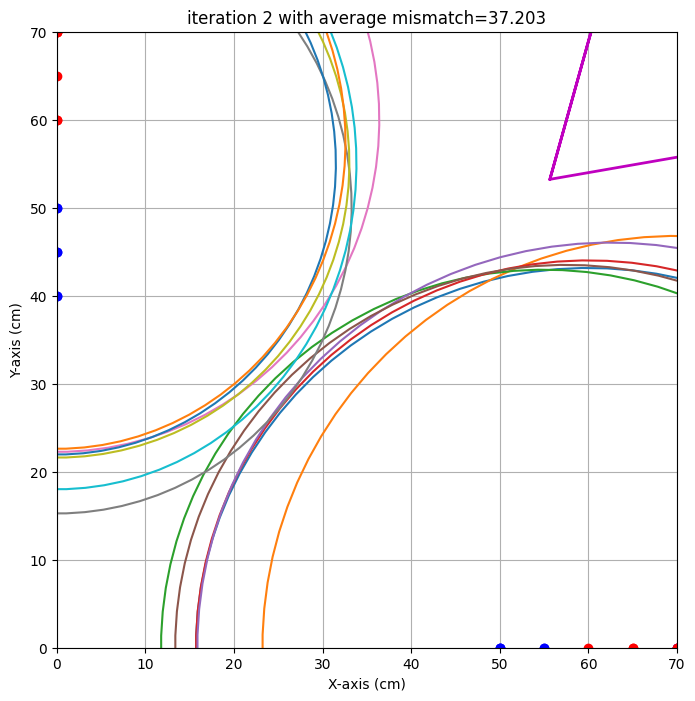

end iteration 2 with average mismatch=37.203


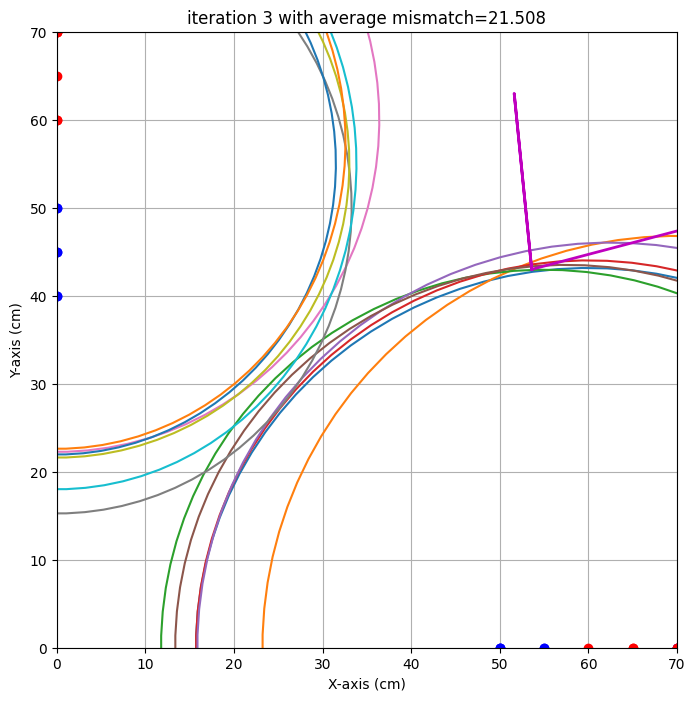

end iteration 3 with average mismatch=21.508


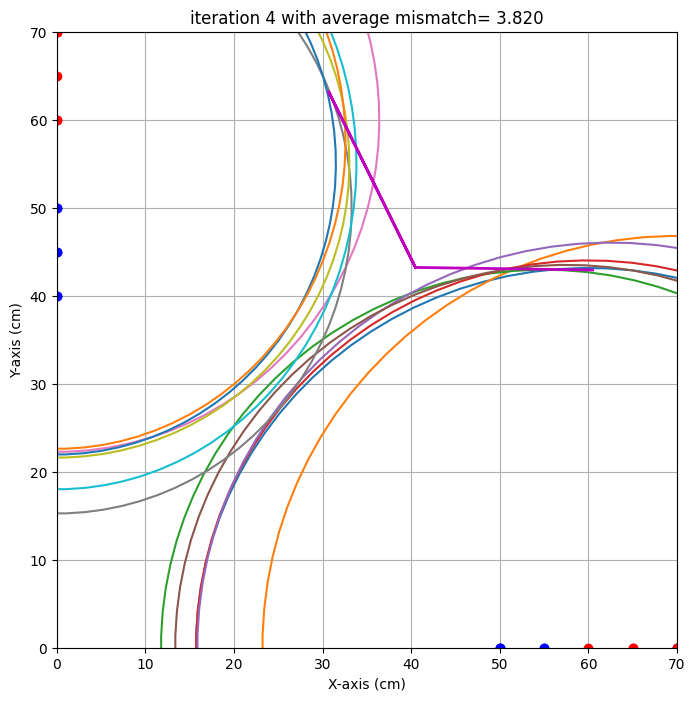

end iteration 4 with average mismatch= 3.820


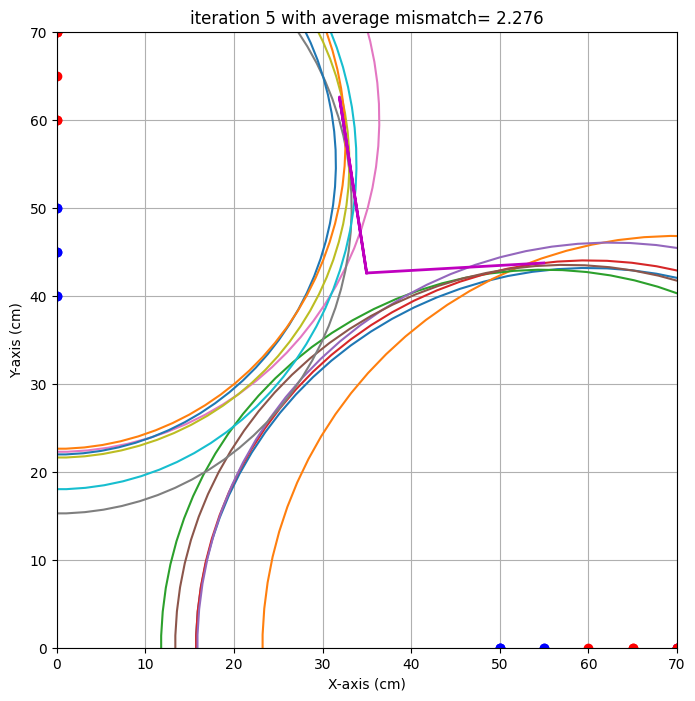

end iteration 5 with average mismatch= 2.276


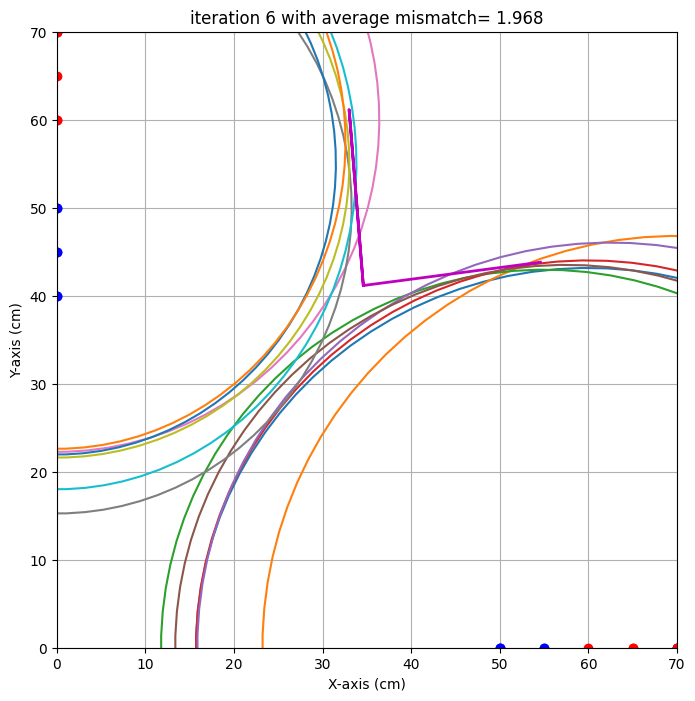

end iteration 6 with average mismatch= 1.968
end iteration 7 with average mismatch= 1.862
end iteration 8 with average mismatch= 1.740
end iteration 9 with average mismatch= 1.666
end iteration 10 with average mismatch= 1.664
end iteration 11 with average mismatch= 1.663
end iteration 12 with average mismatch= 1.663
end iteration 13 with average mismatch= 1.663
end iteration 14 with average mismatch= 1.663
end iteration 15 with average mismatch= 1.663
end iteration 16 with average mismatch= 1.655
end iteration 17 with average mismatch= 1.633
end iteration 18 with average mismatch= 1.633
end iteration 19 with average mismatch= 1.631
end iteration 20 with average mismatch= 1.611
end iteration 21 with average mismatch= 1.611
end iteration 22 with average mismatch= 1.611
end iteration 23 with average mismatch= 1.611
end iteration 24 with average mismatch= 1.611
end iteration 25 with average mismatch= 1.611
end iteration 26 with average mismatch= 1.611
end iteration 27 with average mismatch

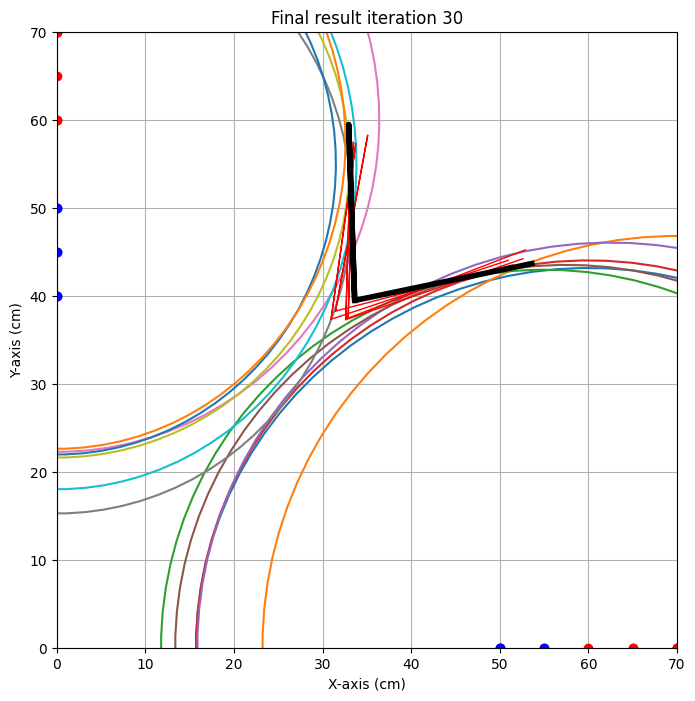

{'alpha': np.float64(11.834437935872732), 'alpha_eps': np.float64(9.3520989240134), 'beta': np.float64(-1.9210226756008013), 'beta_eps': np.float64(12.229976234149328), 'x0': np.float64(33.61771506546014), 'x0_eps': np.float64(2.663442220638064), 'y0': np.float64(39.46372612099658), 'y0_eps': np.float64(2.1779264667944958)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  70   0  50   0  72.2
1  60   0  40   0  70.6
2  60   0  50   0  69.0
3   0  70   0  50  94.5
4   0  60   0  40  93.5
5   0  60   0  50  90.4
6  70   0  40   0  75.4
7   0  70   0  40  93.4


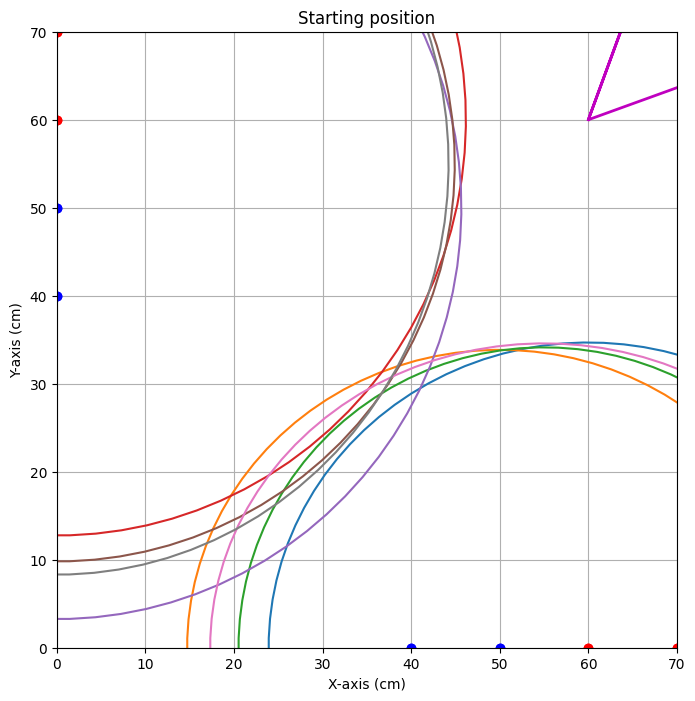


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=45.741


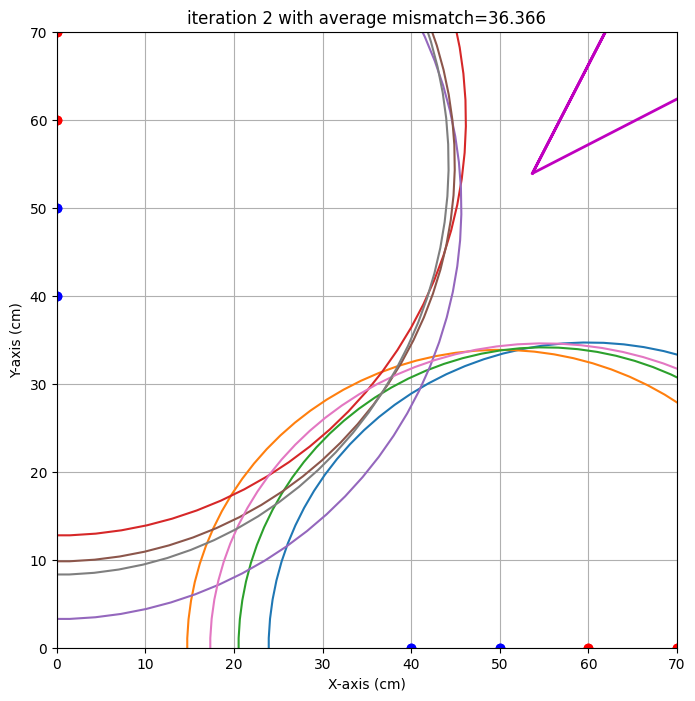

end iteration 2 with average mismatch=36.366


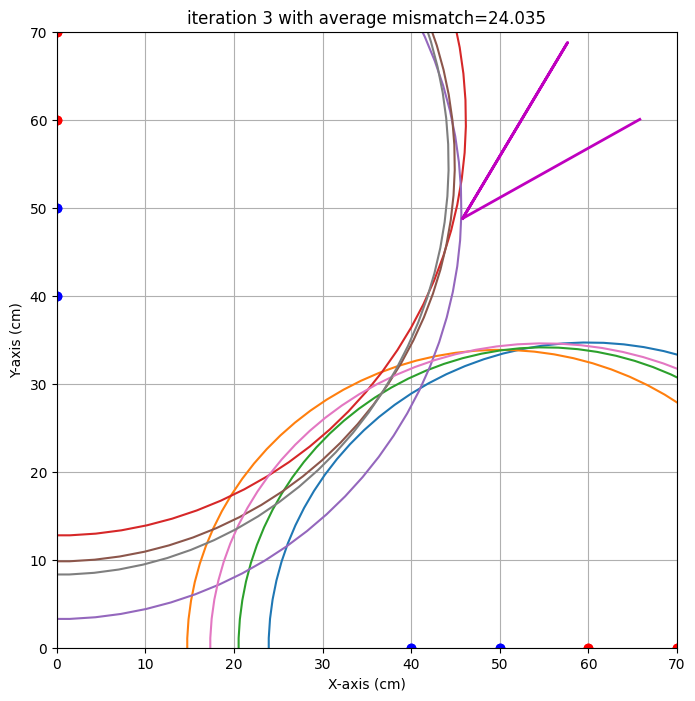

end iteration 3 with average mismatch=24.035


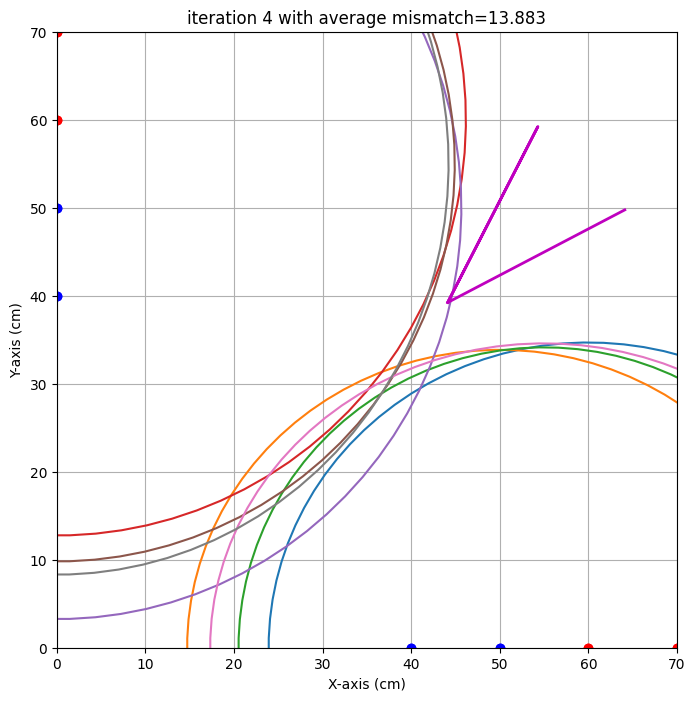

end iteration 4 with average mismatch=13.883


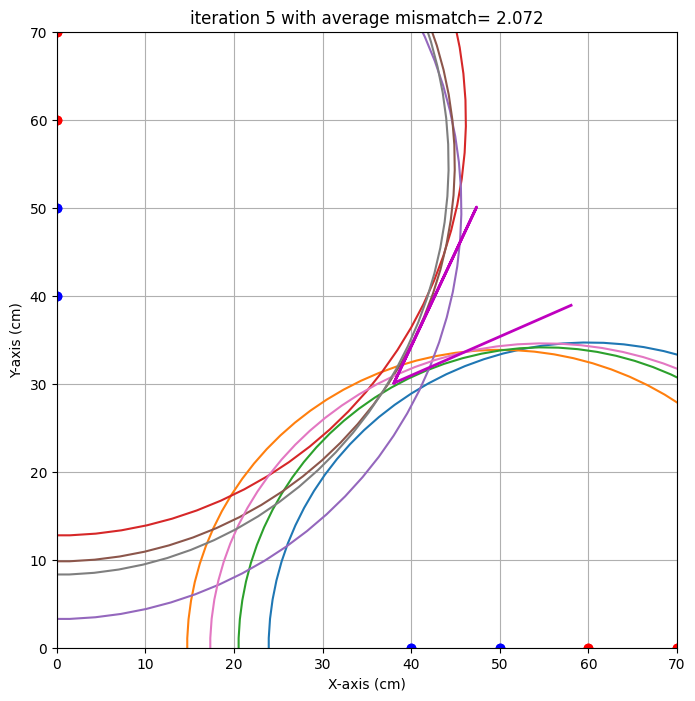

end iteration 5 with average mismatch= 2.072


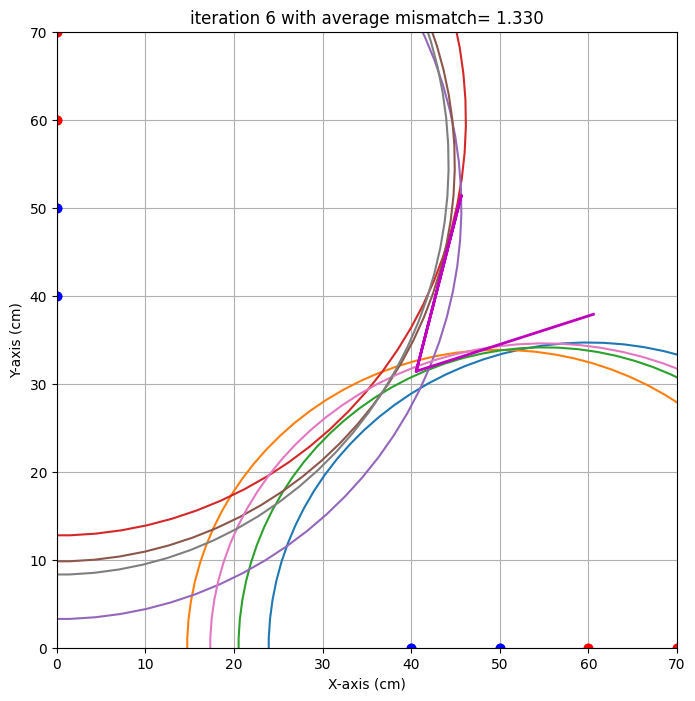

end iteration 6 with average mismatch= 1.330
end iteration 7 with average mismatch= 1.232


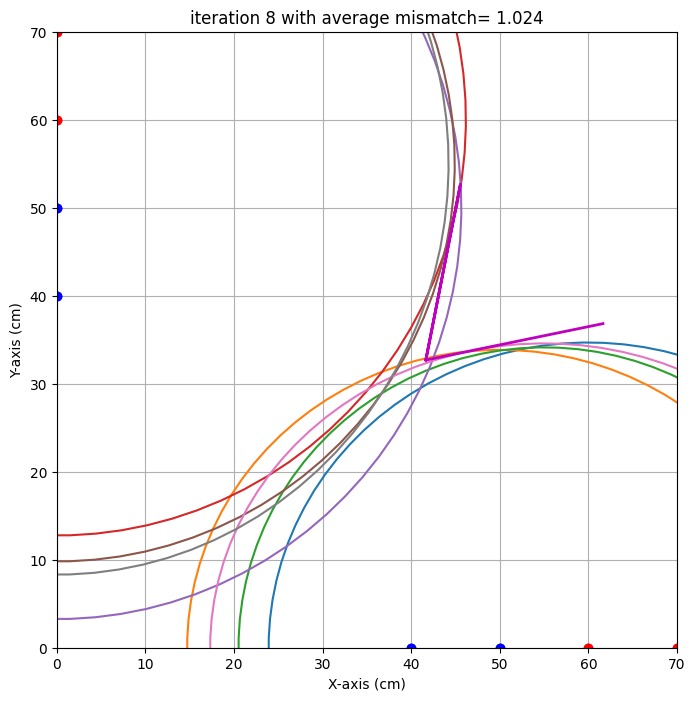

end iteration 8 with average mismatch= 1.024
end iteration 9 with average mismatch= 1.016


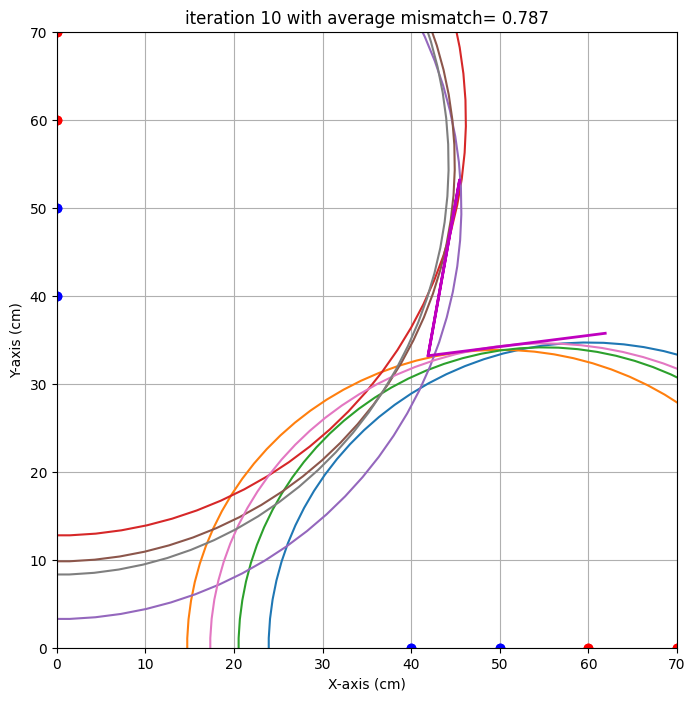

end iteration 10 with average mismatch= 0.787
end iteration 11 with average mismatch= 0.783
end iteration 12 with average mismatch= 0.782


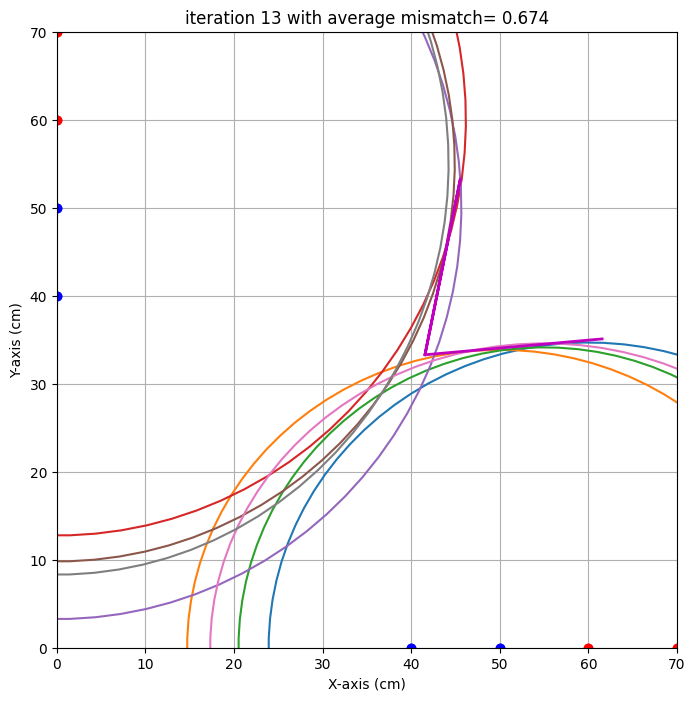

end iteration 13 with average mismatch= 0.674
end iteration 14 with average mismatch= 0.674
end iteration 15 with average mismatch= 0.674
end iteration 16 with average mismatch= 0.674
end iteration 17 with average mismatch= 0.674
end iteration 18 with average mismatch= 0.674
end iteration 19 with average mismatch= 0.674
end iteration 20 with average mismatch= 0.674
end iteration 21 with average mismatch= 0.674
end iteration 22 with average mismatch= 0.674
end iteration 23 with average mismatch= 0.674
end iteration 24 with average mismatch= 0.674
end iteration 25 with average mismatch= 0.674
end iteration 26 with average mismatch= 0.674
end iteration 27 with average mismatch= 0.674
end iteration 28 with average mismatch= 0.674
end iteration 29 with average mismatch= 0.674
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.674
###############################################################

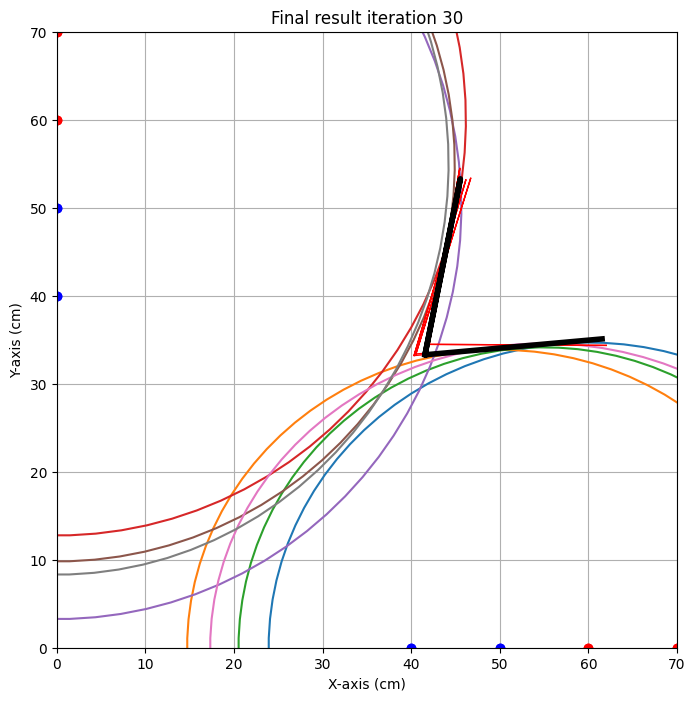

{'alpha': np.float64(5.155029670266785), 'alpha_eps': np.float64(5.4893557668873845), 'beta': np.float64(11.311954456370843), 'beta_eps': np.float64(5.902474891465536), 'x0': np.float64(41.553393393363855), 'x0_eps': np.float64(1.2309873090190422), 'y0': np.float64(33.287201188117294), 'y0_eps': np.float64(1.186586407572996)}
locatie 1 
x0 target is : 31.0. Gevonden waarde: 33.6 cm met een standaardafwijking van 2.7 cm 
y0 target is : 32.7. Gevonden waarde: 39.5 cm met een standaardafwijking van 2.2 cm 
alpha target is : 38.0. Gevonden waarde: 11.8 graden met een standaardafwijking van 9.4 graad 
beta target is : 7.0. Gevonden waarde: -1.9 graden met een standaardafwijking van 12.2 graad 

locatie 2 
x0 target is : 37.0. Gevonden waarde: 41.6 cm met een standaardafwijking van 1.2 cm 
y0 target is : 32.9. Gevonden waarde: 33.3 cm met een standaardafwijking van 1.2 cm 
alpha target is : 4.0. Gevonden waarde: 5.2 graden met een standaardafwijking van 5.5 graad 
beta target is : 23.0. Gevo

In [27]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 31,
                    'y0': 32.7,
                    'alpha' : 38,
                    'beta' : 7},
           'locatie 2':{'x0': 37 ,
                    'y0': 32.9,
                    'alpha' : 4 ,
                    'beta' : 23 }
            }
           
# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [70,0,50,0,88.6],
    #[60,0,40,0,200],
    [70,0,70,0,93.6],
    [60,0,50,0,86.5],
    [65,0,55,0,88.6],
    [70,0,55,0,93.3],  
    [65,0,50,0,88.3],
    [0,70,0,50,75.5],
    [0,60,0,40,69.5],
    [0,60,0,50,66.8],
    [0,70,0,40,74.0],
    [0,65,0,45,66.1],
    #[0,70,0,60,200],
    #[0,70,0,55,200],
    [0,70,0,45,69.8],

   
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [70,0,50,0,72.2],
    [60,0,40,0,70.6],
    [60,0,50,0,69.0],
    [0,70,0,50,94.5],  
    [0,60,0,40,93.5],
    [0,60,0,50,90.4],
    [70,0,40,0,75.4],
    [0,70,0,40,93.4],
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
    xs  ys  xr  yr     R
0   70   0  50   0  92.2
1   60   0  40   0  93.5
2   60   0  50   0  89.2
3   70   0  40   0  93.5
4   65   0  45   0  91.0
5   70   0  45   0  93.5
6    0  20   0  40  95.3
7    0  30   0  50  89.5
8    0  30   0  40  89.0
9    0  20   0  50  93.2
10   0  25   0  45  90.9
11   0  35   0  25  95.5


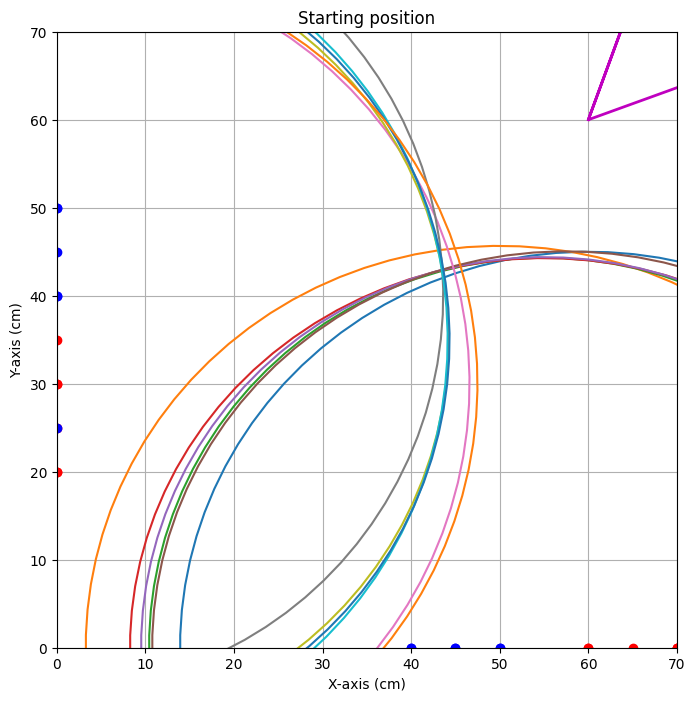


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=42.009


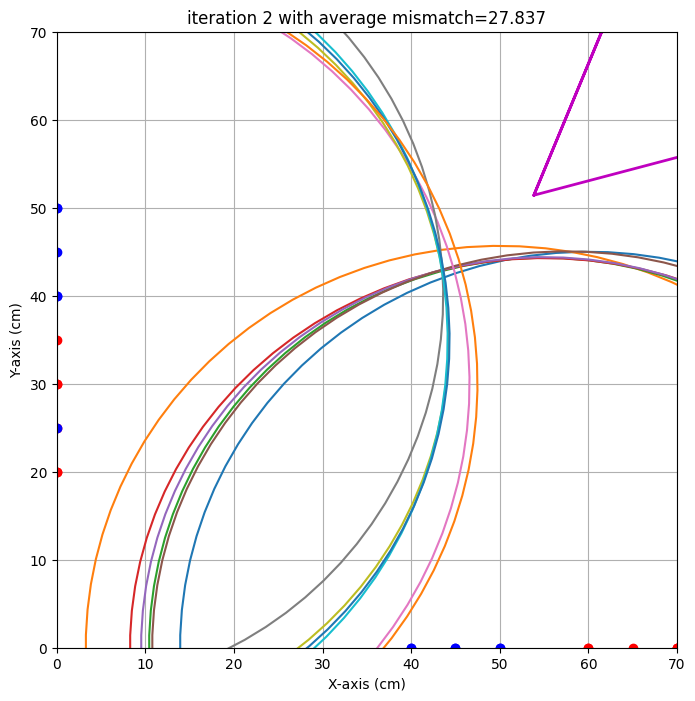

end iteration 2 with average mismatch=27.837


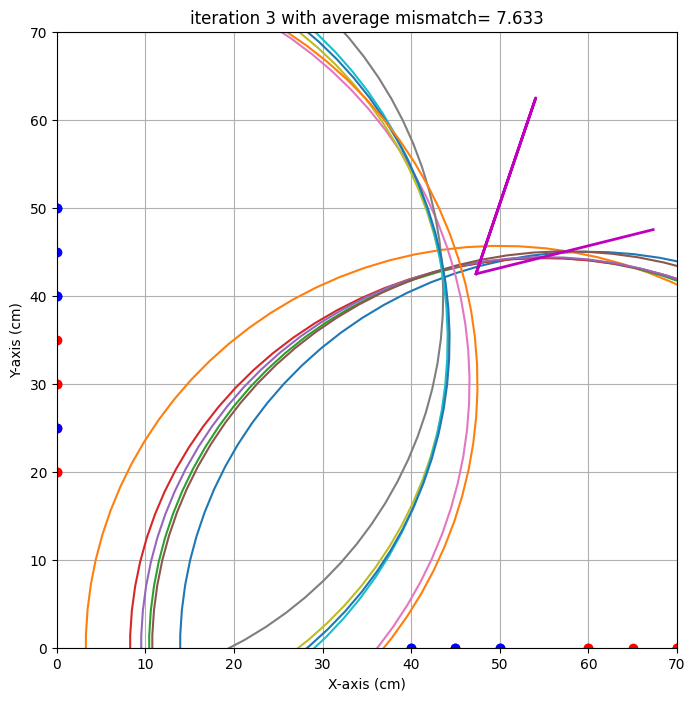

end iteration 3 with average mismatch= 7.633


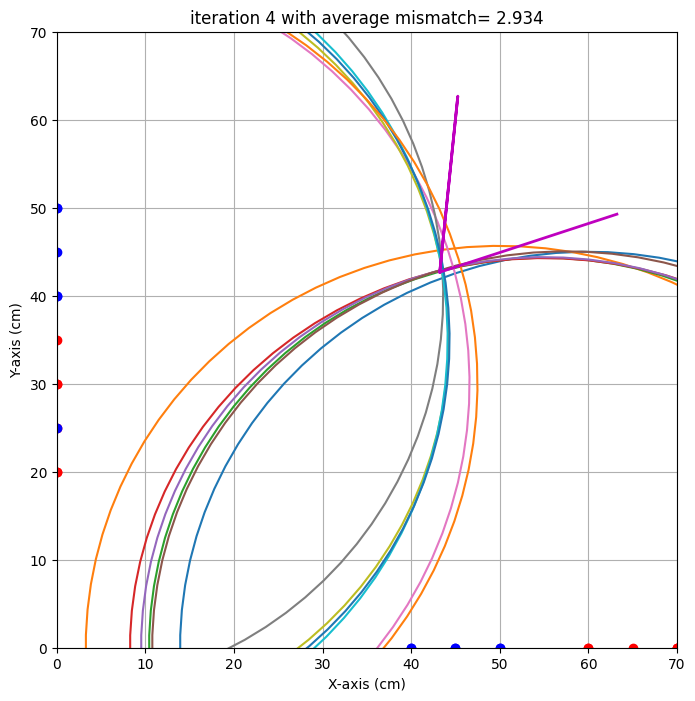

end iteration 4 with average mismatch= 2.934


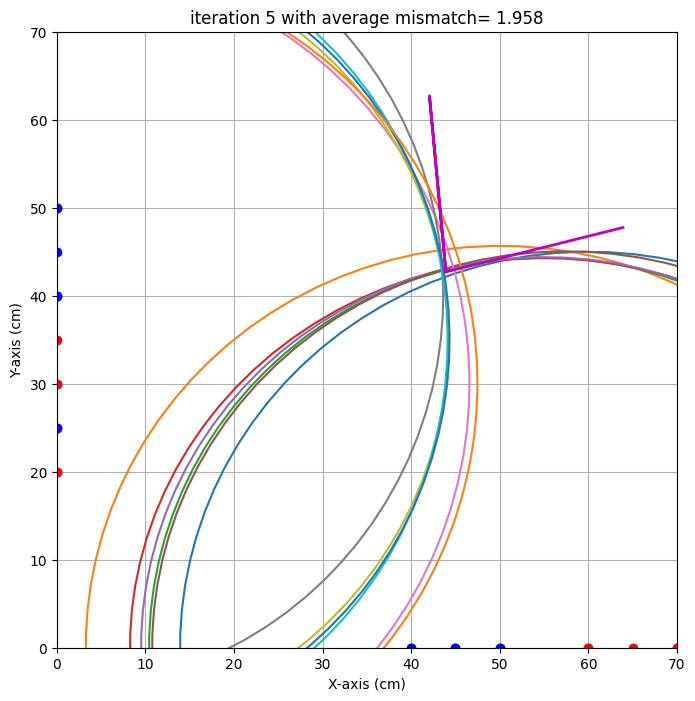

end iteration 5 with average mismatch= 1.958


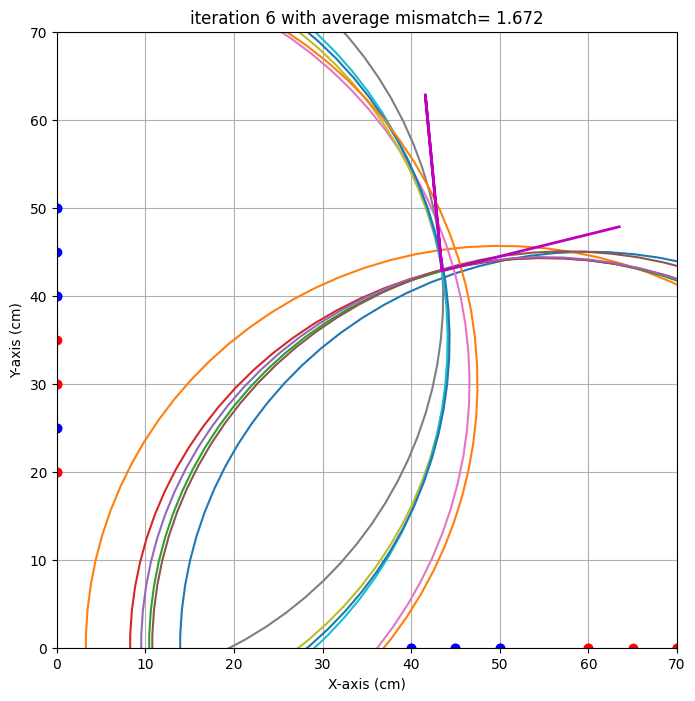

end iteration 6 with average mismatch= 1.672
end iteration 7 with average mismatch= 1.670
end iteration 8 with average mismatch= 1.670
end iteration 9 with average mismatch= 1.670
end iteration 10 with average mismatch= 1.584


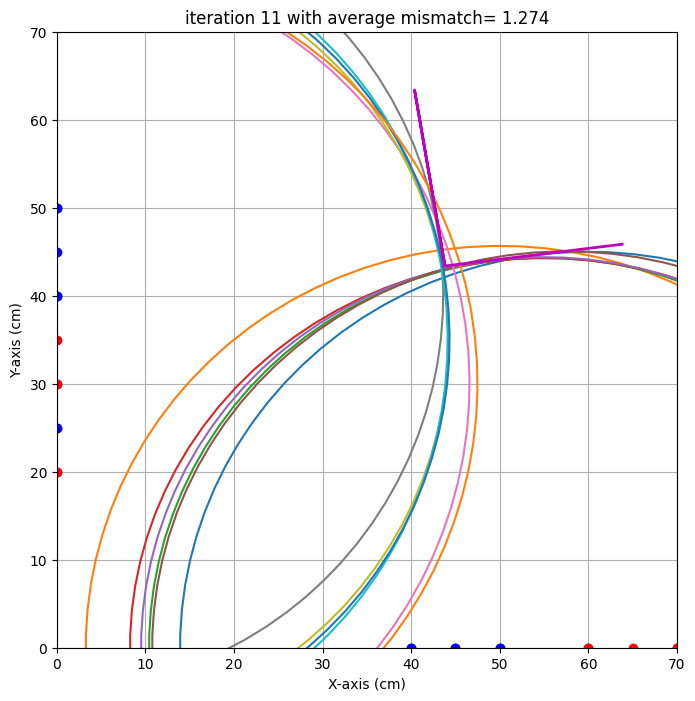

end iteration 11 with average mismatch= 1.274
end iteration 12 with average mismatch= 1.217
end iteration 13 with average mismatch= 1.212
end iteration 14 with average mismatch= 1.212
end iteration 15 with average mismatch= 1.212
end iteration 16 with average mismatch= 1.212
end iteration 17 with average mismatch= 1.212
end iteration 18 with average mismatch= 1.212
end iteration 19 with average mismatch= 1.207
end iteration 20 with average mismatch= 1.174
end iteration 21 with average mismatch= 1.123
end iteration 22 with average mismatch= 1.091
end iteration 23 with average mismatch= 1.091
end iteration 24 with average mismatch= 1.091
end iteration 25 with average mismatch= 1.091
end iteration 26 with average mismatch= 1.060
end iteration 27 with average mismatch= 1.046
end iteration 28 with average mismatch= 1.045
end iteration 29 with average mismatch= 1.045
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 

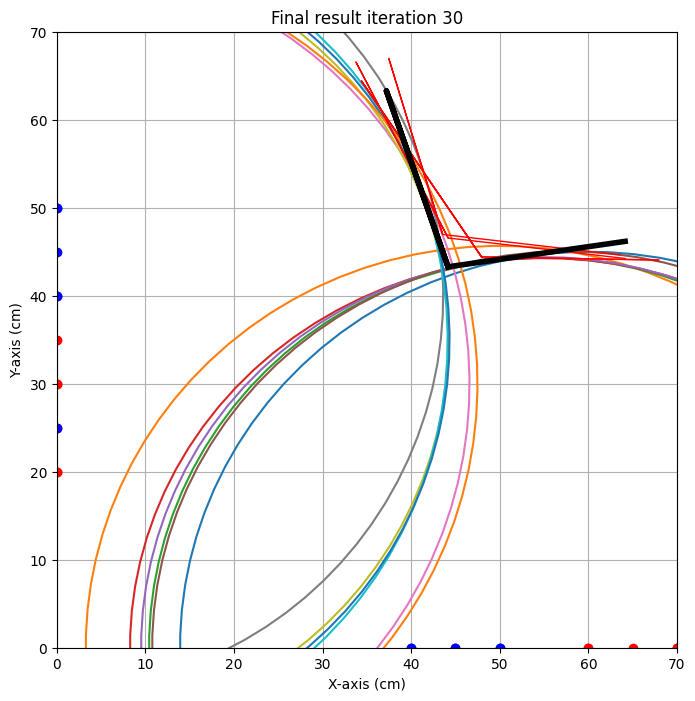

{'alpha': np.float64(8.22874982293482), 'alpha_eps': np.float64(14.880548261030276), 'beta': np.float64(-19.194432822496392), 'beta_eps': np.float64(14.94037487993008), 'x0': np.float64(44.15881372161666), 'x0_eps': np.float64(3.782222358701233), 'y0': np.float64(43.28514977464844), 'y0_eps': np.float64(3.675960978378953)}
test locatie 
x0 target is : 43.0. Gevonden waarde: 44.2 cm met een standaardafwijking van 3.8 cm 
y0 target is : 43.9. Gevonden waarde: 43.3 cm met een standaardafwijking van 3.7 cm 
alpha target is : 7.0. Gevonden waarde: 8.2 graden met een standaardafwijking van 14.9 graad 
beta target is : -17.0. Gevonden waarde: -19.2 graden met een standaardafwijking van 14.9 graad 



In [28]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 43 ,
                    'y0': 43.9 ,
                    'alpha' : 7 ,
                    'beta' : -17 
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [70,0,50,0,92.2],
                    [60,0,40,0,93.5],
                    [60,0,50,0,89.2],
                    [70,0,40,0,93.5],
                    [65,0,45,0,91.0],
                    [70,0,45,0,93.5],
                    #[0,70,0,50,200],
                    [0,20,0,40,95.3],
                    [0,30,0,50,89.5],
                    [0,30,0,40,89.0],
                    [0,20,0,50,93.2],
                    [0,25,0,45,90.9],
                    [0,35,0,25,95.5],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")